<a href="https://colab.research.google.com/github/silmucci/Progetto_DL_Rilevamento_Danni_Auto/blob/main/Progetto_DL_Rilevamento_Danni_Auto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto DL – Rilevazione danni alla carrozzeria con YOLO11

**Obiettivo del progetto:** addestrare/fare fine-tuning di un modello di Computer Vision per individuare e classificare danni alla carrozzeria di automobili a partire da immagini.

In questo notebook viene implementata la parte di **Deep Learning**:

1. collegamento a Google Drive;
2. installazione e import delle librerie;
3. caricamento del dataset in formato YOLO;
4. controllo della struttura del dataset;
5. fine-tuning di YOLO11 sulle classi di interesse;
6. validazione del modello;
7. predizione su immagini di validazione e su immagini caricate manualmente;
8. salvataggio del modello addestrato su Google Drive.
Questo notebook usa **YOLO11 per object detection**, quindi produce bounding box e classi del danno.

## 1. Collegamento a Google Drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

DATA_YAML = Path("/content/car_damage_dataset/data.yaml")
DATASET_DIR = Path("/content/car_damage_dataset")

print("data.yaml esiste?", DATA_YAML.exists())
print("Percorso:", DATA_YAML)

data.yaml esiste? True
Percorso: /content/car_damage_dataset/data.yaml


## 2. Installazione delle librerie

Ultralytics contiene l'implementazione di YOLO11 e le funzioni per training, validazione e predizione.

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
from pathlib import Path
import glob
import os
import zipfile

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Percorsi e parametri principali


In [ ]:
# Percorso del file ZIP scaricato da Roboflow e caricato su Colab
ZIP_PATH = Path('/content/drive/MyDrive/car damage detected dataset CrackDentSctratch.v1-raw.yolov11.zip')


# Cartella in cui verrà estratto il dataset
DATASET_DIR = Path('/content/car_damage_dataset')
DATA_YAML = DATASET_DIR / 'data.yaml'

# Cartella su Google Drive in cui salvare automaticamente training e pesi
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/yolo_car_damage_models'
RUN_NAME = 'train_car_damage_yolo11n'

# Parametri di training
EPOCHS = 100
IMGSZ = 1024
BATCH = 16
CONF = 0.25

# Se modello già  addestrato, inserire qui il percorso del best.pt e saltare il training.
# Esempio: EXISTING_BEST_MODEL_PATH = '/content/drive/MyDrive/yolo_car_damage_models/train-1_saved-8/weights/best.pt'
EXISTING_BEST_MODEL_PATH = None

In [ ]:
RESUME_TRAINING = True # Imposta a True per riprendere il training da dove si era interrotto (usa i pesi 'last.pt' dalla cartella del progetto)

## 4. Estrazione del dataset


In [ ]:
if DATA_YAML.exists():
    print('Dataset già estratto in:', DATASET_DIR)
else:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"""File ZIP non trovato: {ZIP_PATH}
Carica il dataset ZIP su Colab oppure modifica ZIP_PATH."""
        )

    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    print('Dataset estratto in:', DATASET_DIR)

Dataset già estratto in: /content/car_damage_dataset


## 5. Controllo della struttura del dataset

Questa cella verifica che immagini, label e `data.yaml` siano presenti correttamente.

In [ ]:
if DATA_YAML.exists():
    print('Dataset già estratto in:', DATASET_DIR)
else:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"""File ZIP non trovato: {ZIP_PATH}\nCarica il dataset ZIP su Colab oppure modifica ZIP_PATH."""
        )

    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    print('Dataset estratto in:', DATASET_DIR)

print('Contenuto della cartella dataset:')
for item in sorted(DATASET_DIR.iterdir()):
    print('-', item.name)

print('Contenuto di data.yaml:')
print(DATA_YAML.read_text())

print('Numero di immagini e label per split:')
for split in ['train', 'valid', 'test']:
    images_dir = DATASET_DIR / split / 'images'
    labels_dir = DATASET_DIR / split / 'labels'

    if images_dir.exists():
        n_images = len(list(images_dir.glob('*')))
        n_labels = len(list(labels_dir.glob('*.txt'))) if labels_dir.exists() else 0
        print(f'{split}: {n_images} immagini, {n_labels} label')
    else:
        print(f'{split}: cartella non presente')

Dataset già estratto in: /content/car_damage_dataset
Contenuto della cartella dataset:
- README.dataset.txt
- README.roboflow.txt
- data.yaml
- train
- valid
Contenuto di data.yaml:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['crack', 'dent', 'scratch']

roboflow:
  workspace: nibm-7v215
  project: car-damage-detected-dataset-crackdentsctratch
  version: 1
  license: MIT
  url: https://universe.roboflow.com/nibm-7v215/car-damage-detected-dataset-crackdentsctratch/dataset/1
Numero di immagini e label per split:
train: 3239 immagini, 3239 label
valid: 902 immagini, 902 label
test: cartella non presente


## 6. Fine-tuning di YOLO11

Il modello parte dai pesi pre-addestrati `yolo11n.pt` e viene adattato alle classi del dataset. I risultati vengono salvati direttamente su Google Drive.

### Riprendere un training interrotto
Se l'addestramento viene interrotto (ad esempio per timeout di Colab o disconnessione), è possibile riprenderlo impostando la variabile `RESUME_TRAINING = True` nella cella dei parametri. Il training riprenderà automaticamente dall'ultima epoca salvata ('last.pt') nella cartella del progetto su Drive.

In [ ]:
model = YOLO('yolo11n.pt')

model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    project=DRIVE_PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True
)

BEST_MODEL_PATH = Path(DRIVE_PROJECT_DIR) / RUN_NAME / 'weights' / 'best.pt'
print('Modello migliore salvato in:', BEST_MODEL_PATH)

## 7. Caricamento del modello addestrato

Questa cella carica il `best.pt`.

In [ ]:
if EXISTING_BEST_MODEL_PATH is not None:
    BEST_MODEL_PATH = Path(EXISTING_BEST_MODEL_PATH)
else:
    BEST_MODEL_PATH = Path(DRIVE_PROJECT_DIR) / RUN_NAME / 'weights' / 'best.pt'

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f'Modello non trovato: {BEST_MODEL_PATH}'
        'Esegui prima il training oppure imposta EXISTING_BEST_MODEL_PATH.'
    )

loaded_model = YOLO(str(BEST_MODEL_PATH))
print('Modello caricato da:', BEST_MODEL_PATH)

Modello caricato da: /content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/weights/best.pt


## 8. Validazione del modello

La validazione misura le prestazioni del modello sul validation set, ad esempio precision, recall e mAP.

In [ ]:
from pathlib import Path
import zipfile

DATASET_DIR = Path('/content/car_damage_dataset')
DATA_YAML = DATASET_DIR / 'data.yaml'
IMGSZ = 1024
BATCH = 16


ZIP_PATH = Path('/content/drive/MyDrive/car damage detected dataset CrackDentSctratch.v1-raw.yolov11.zip')

if DATA_YAML.exists():
    print('Dataset already extracted in:', DATASET_DIR)
else:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"File ZIP not found: {ZIP_PATH}\n"
            "Upload the ZIP dataset to Colab or modify ZIP_PATH."
        )

    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)

    print('Dataset extracted in:', DATASET_DIR)

metrics = loaded_model.val(
    data=str(DATA_YAML),
    imgsz=IMGSZ,
    batch=BATCH
)

Dataset already extracted in: /content/car_damage_dataset
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 970.9±397.7 MB/s, size: 32.6 KB)
val: Scanning /content/car_damage_dataset/valid/labels.cache... 902 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 902/902 343.9Mit/s 0.0s
val: /content/car_damage_dataset/valid/images/car41-1-_jpg.rf.373f4ef07992cc6d0d93dfa89de7c64a.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0119]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 3.1it/s 18.2s
                   all        901       1973      0.539      0.438       0.44      0.239
                 crack        490        605      0.688      0.651      0.679      0.423
                  dent        375        525      0.509

#8.1 Generazione Curve di Validazione

In [ ]:
from ultralytics import YOLO
from pathlib import Path

BEST_MODEL_PATH = Path(DRIVE_PROJECT_DIR) / RUN_NAME / "weights" / "best.pt"

loaded_model = YOLO(str(BEST_MODEL_PATH))

metrics = loaded_model.val(
    data=str(DATA_YAML),
    imgsz=IMGSZ,
    batch=BATCH,
    plots=True,
    project=DRIVE_PROJECT_DIR,
    name=RUN_NAME + "_val_plots",
    exist_ok=True
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1348.9±350.6 MB/s, size: 34.2 KB)
val: Scanning /content/car_damage_dataset/valid/labels.cache... 902 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 902/902 315.3Mit/s 0.0s
val: /content/car_damage_dataset/valid/images/car41-1-_jpg.rf.373f4ef07992cc6d0d93dfa89de7c64a.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0119]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 2.9it/s 19.5s
                   all        901       1973      0.539      0.438       0.44      0.239
                 crack        490        605      0.688      0.651      0.679      0.423
                  dent        375        525      0.509      0.425      0.421      0.198
               scratch 

## 8.2 Visualizzazione dei grafici prodotti da Ultralytics

In [ ]:
from pathlib import Path

BASE_DIR = Path(DRIVE_PROJECT_DIR)

for p in BASE_DIR.rglob("*.png"):
    print(p)

/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/BoxPR_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/BoxF1_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/BoxP_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/BoxR_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/confusion_matrix_normalized.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/confusion_matrix.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/results.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n_val_plots/BoxPR_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n_val_plots/BoxF1_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n_val_plots/BoxP_curve.png
/content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n_val_plots/BoxR_


BoxPR_curve.png
Esiste? True


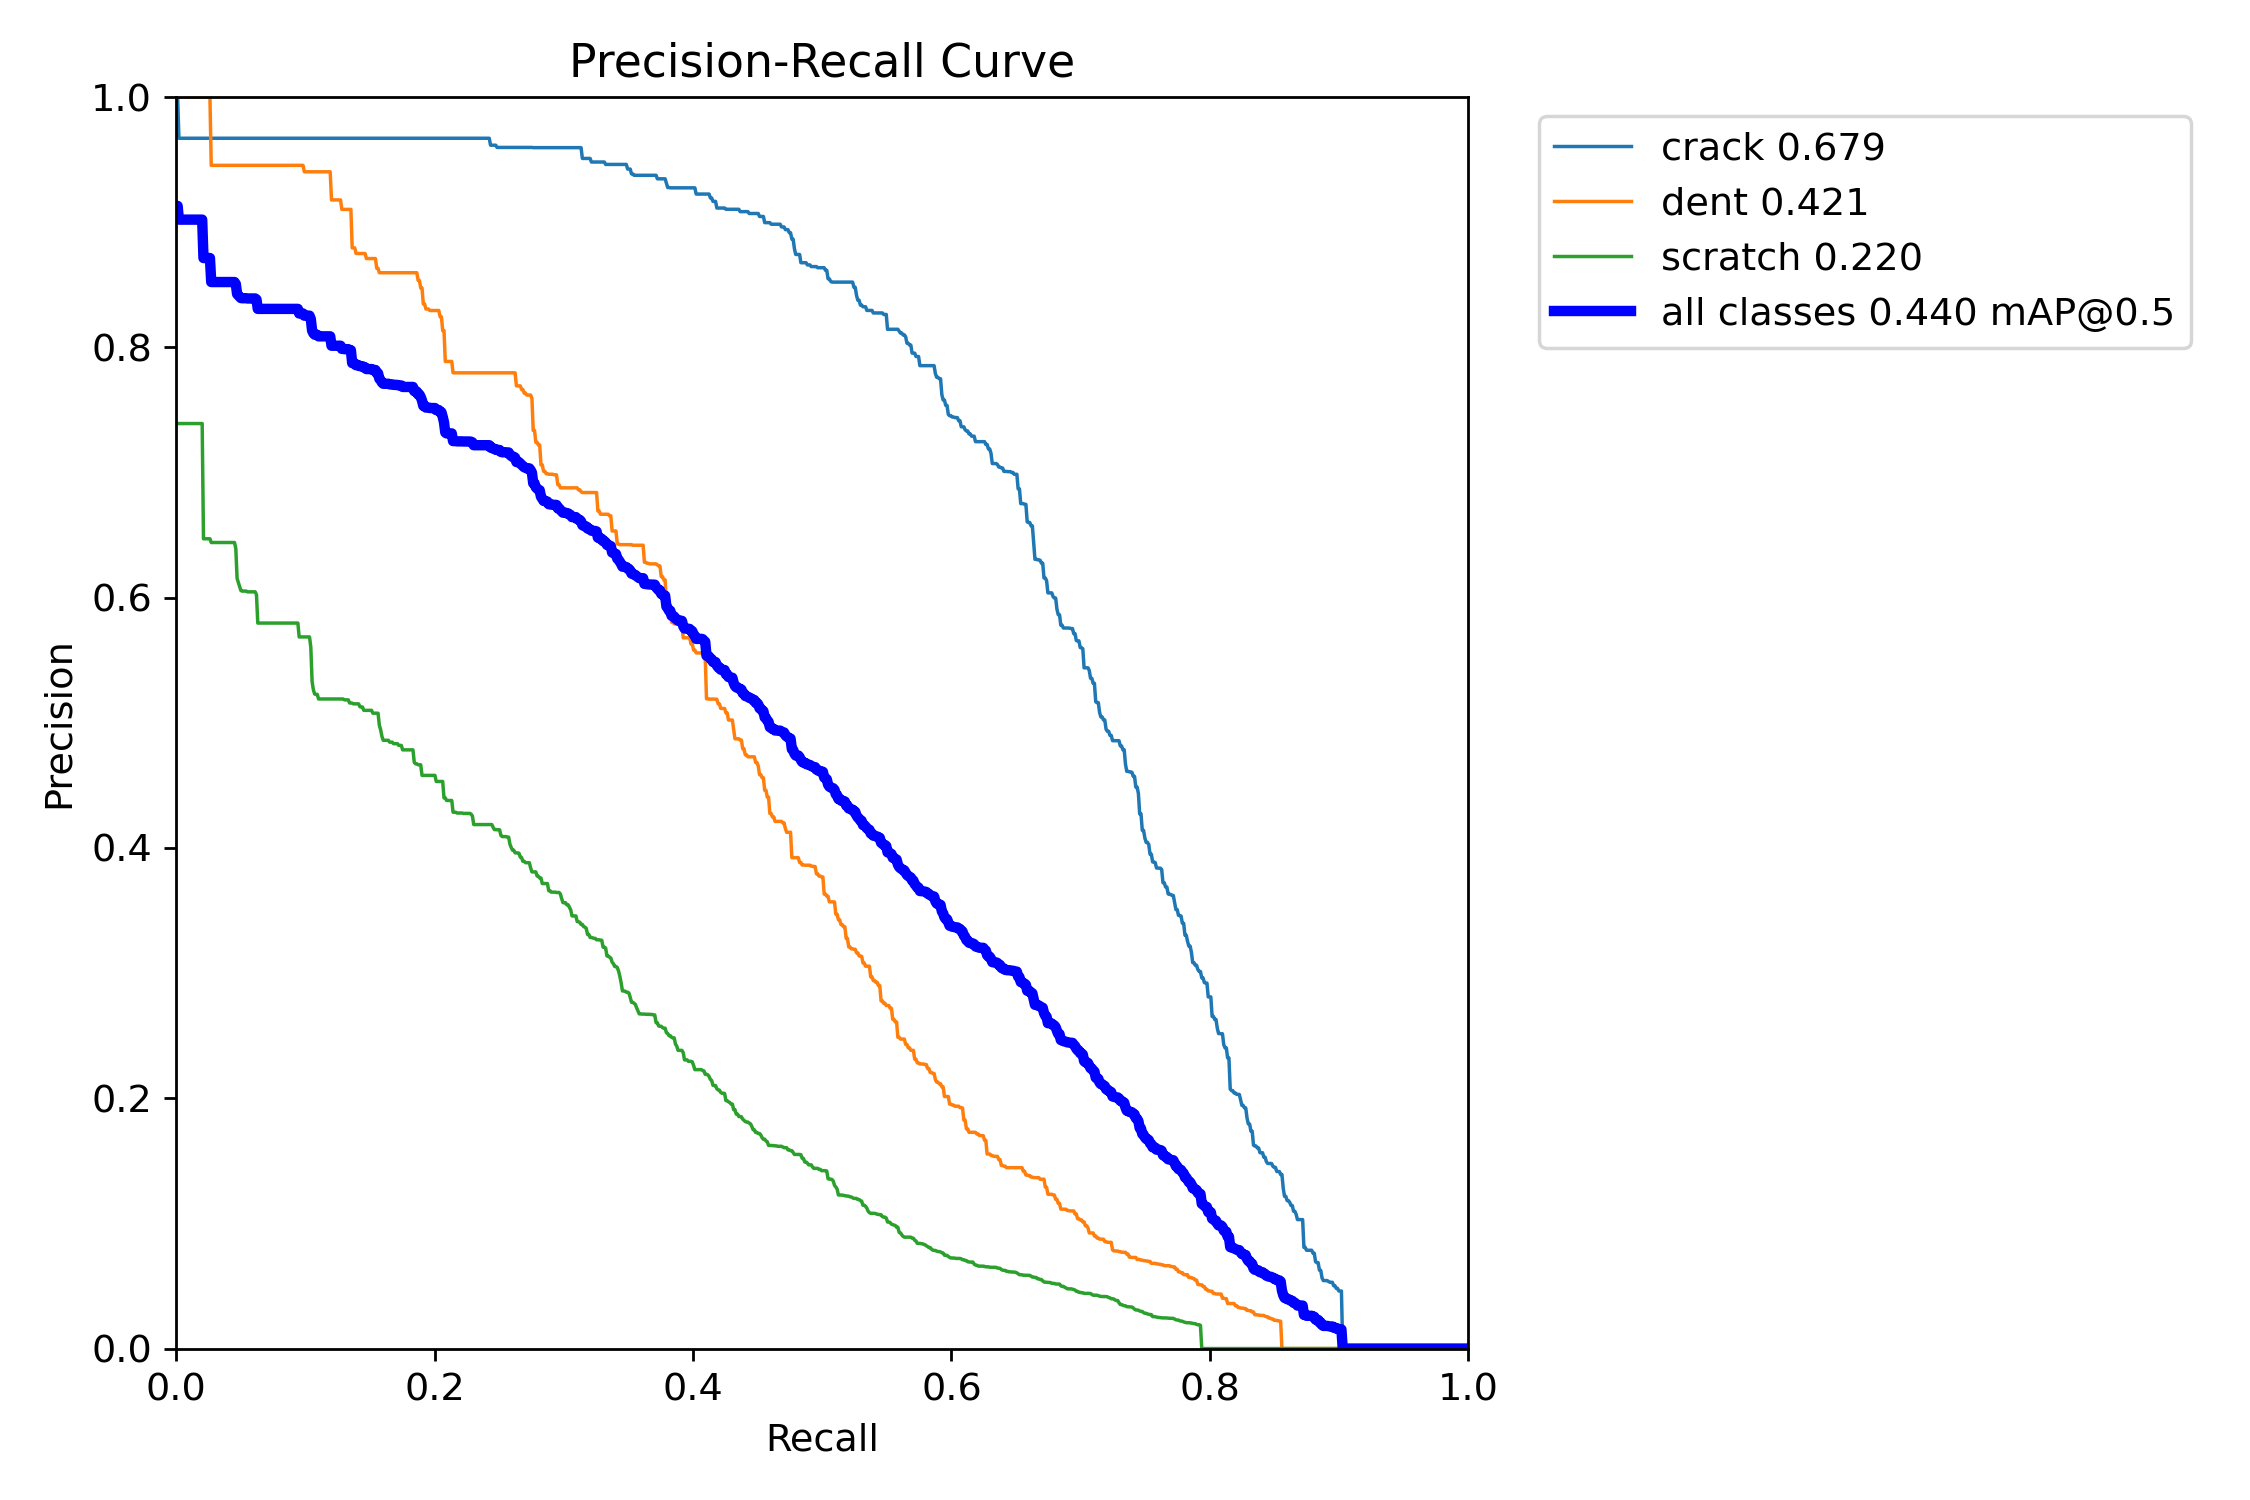


BoxF1_curve.png
Esiste? True


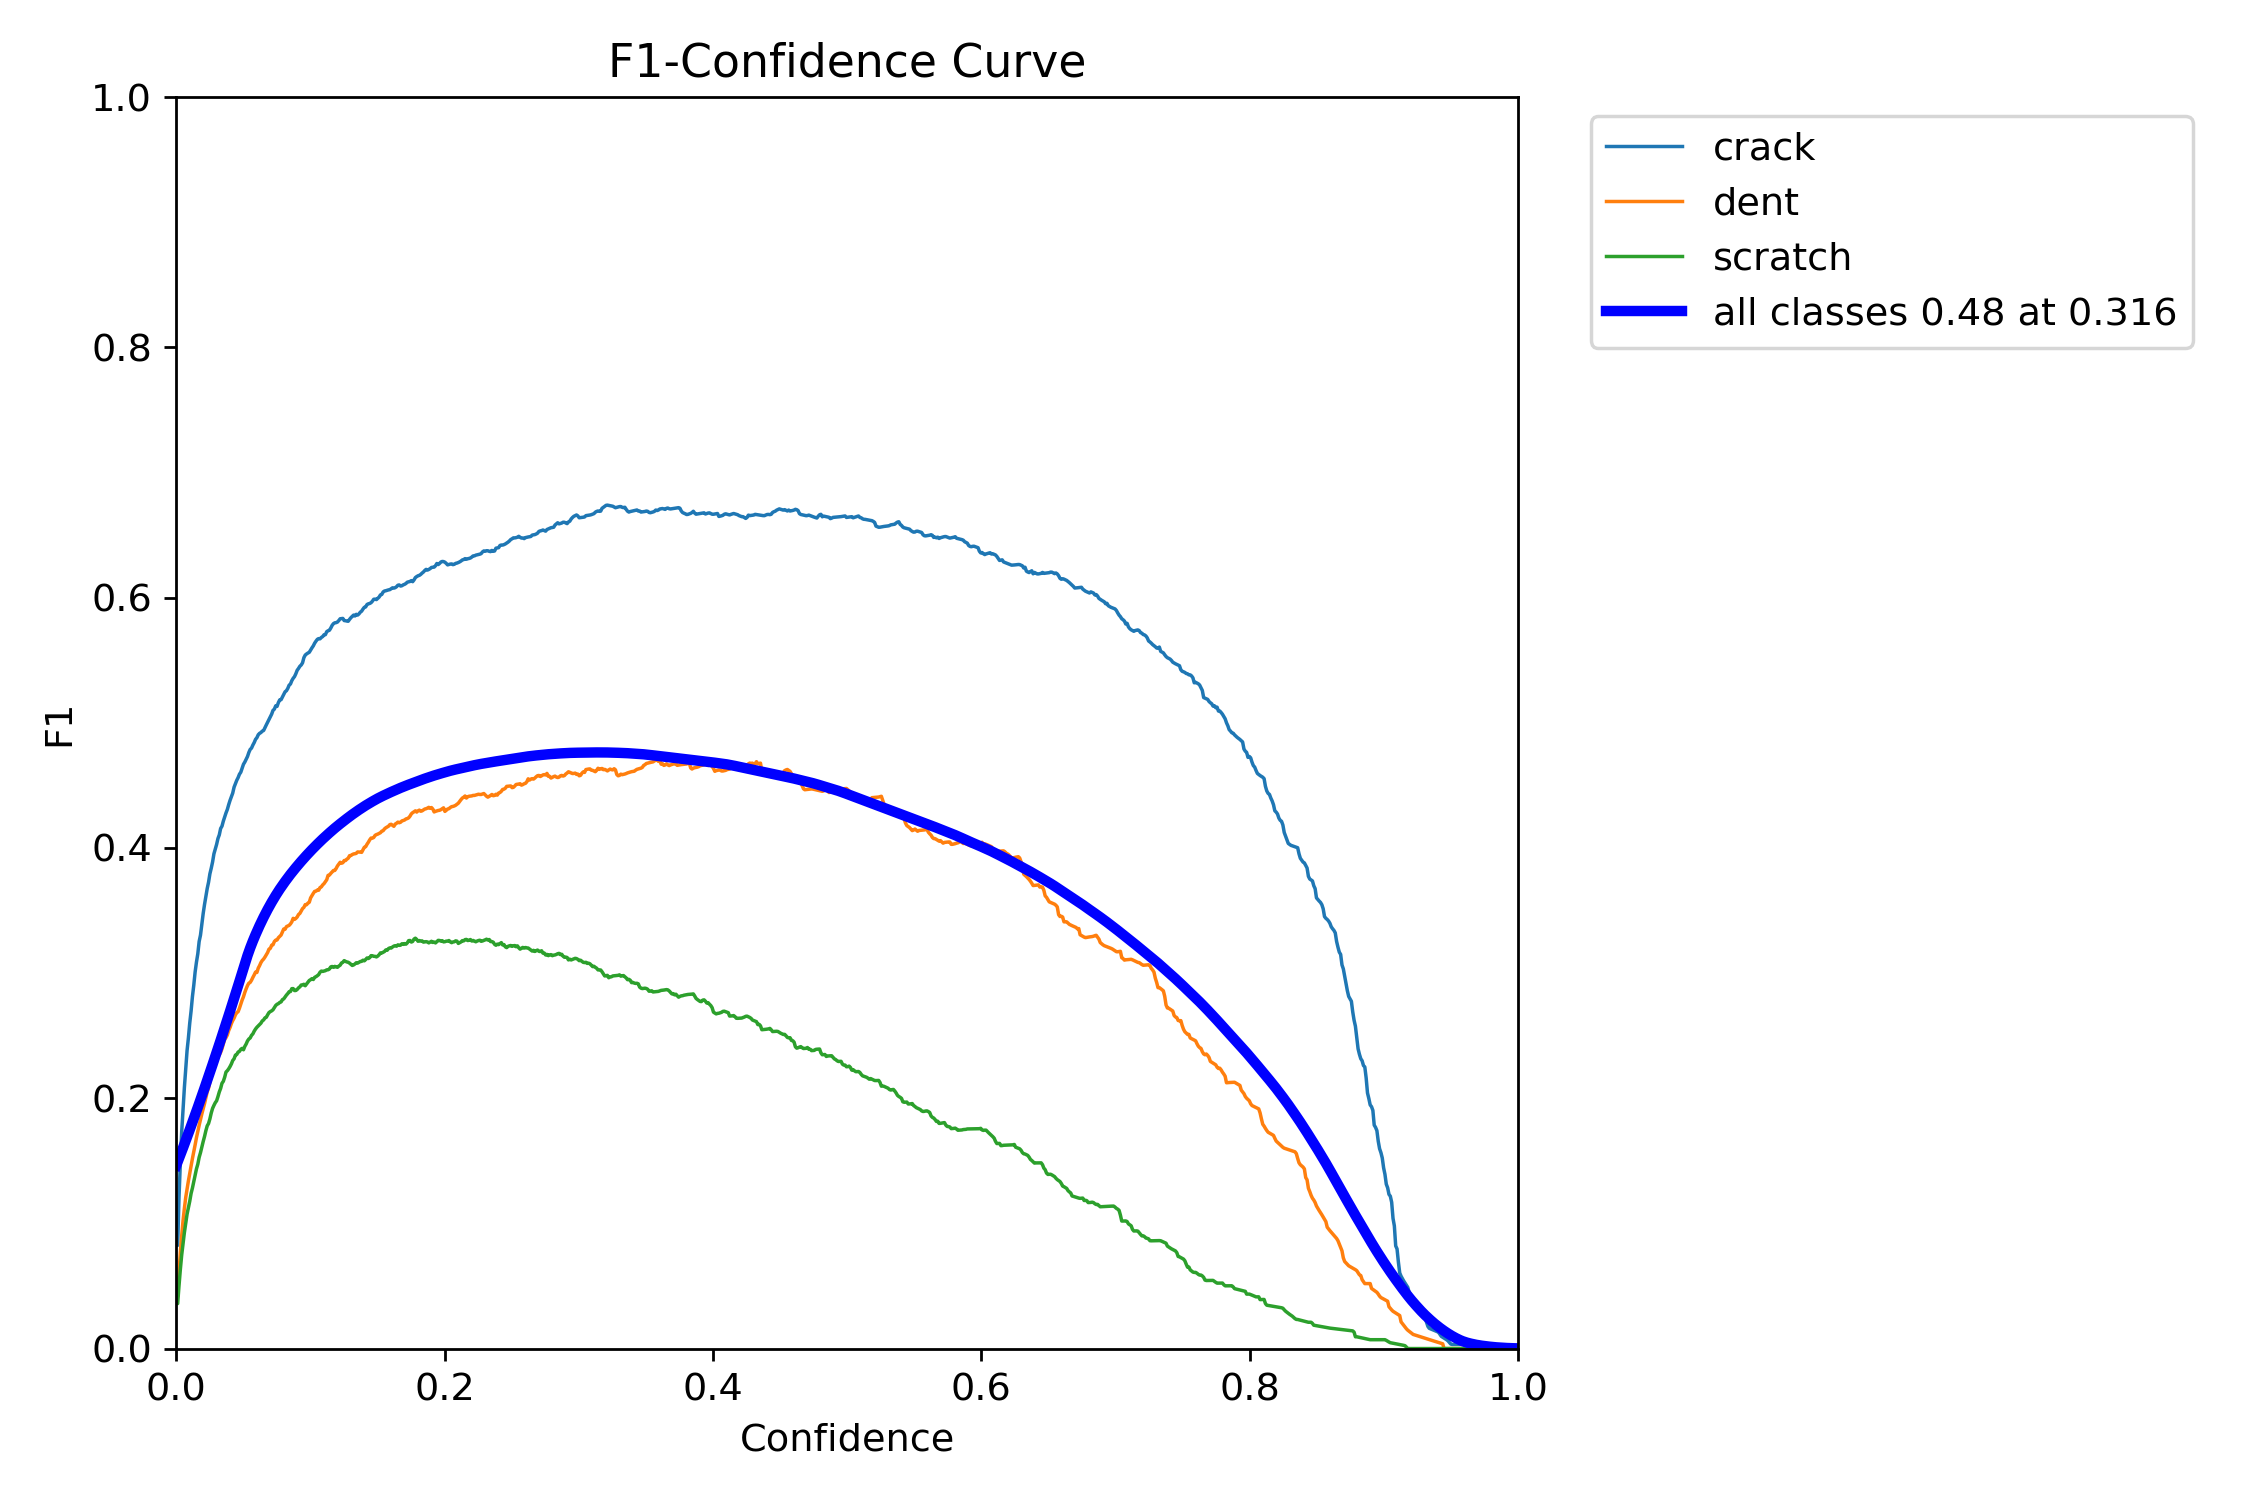


BoxP_curve.png
Esiste? True


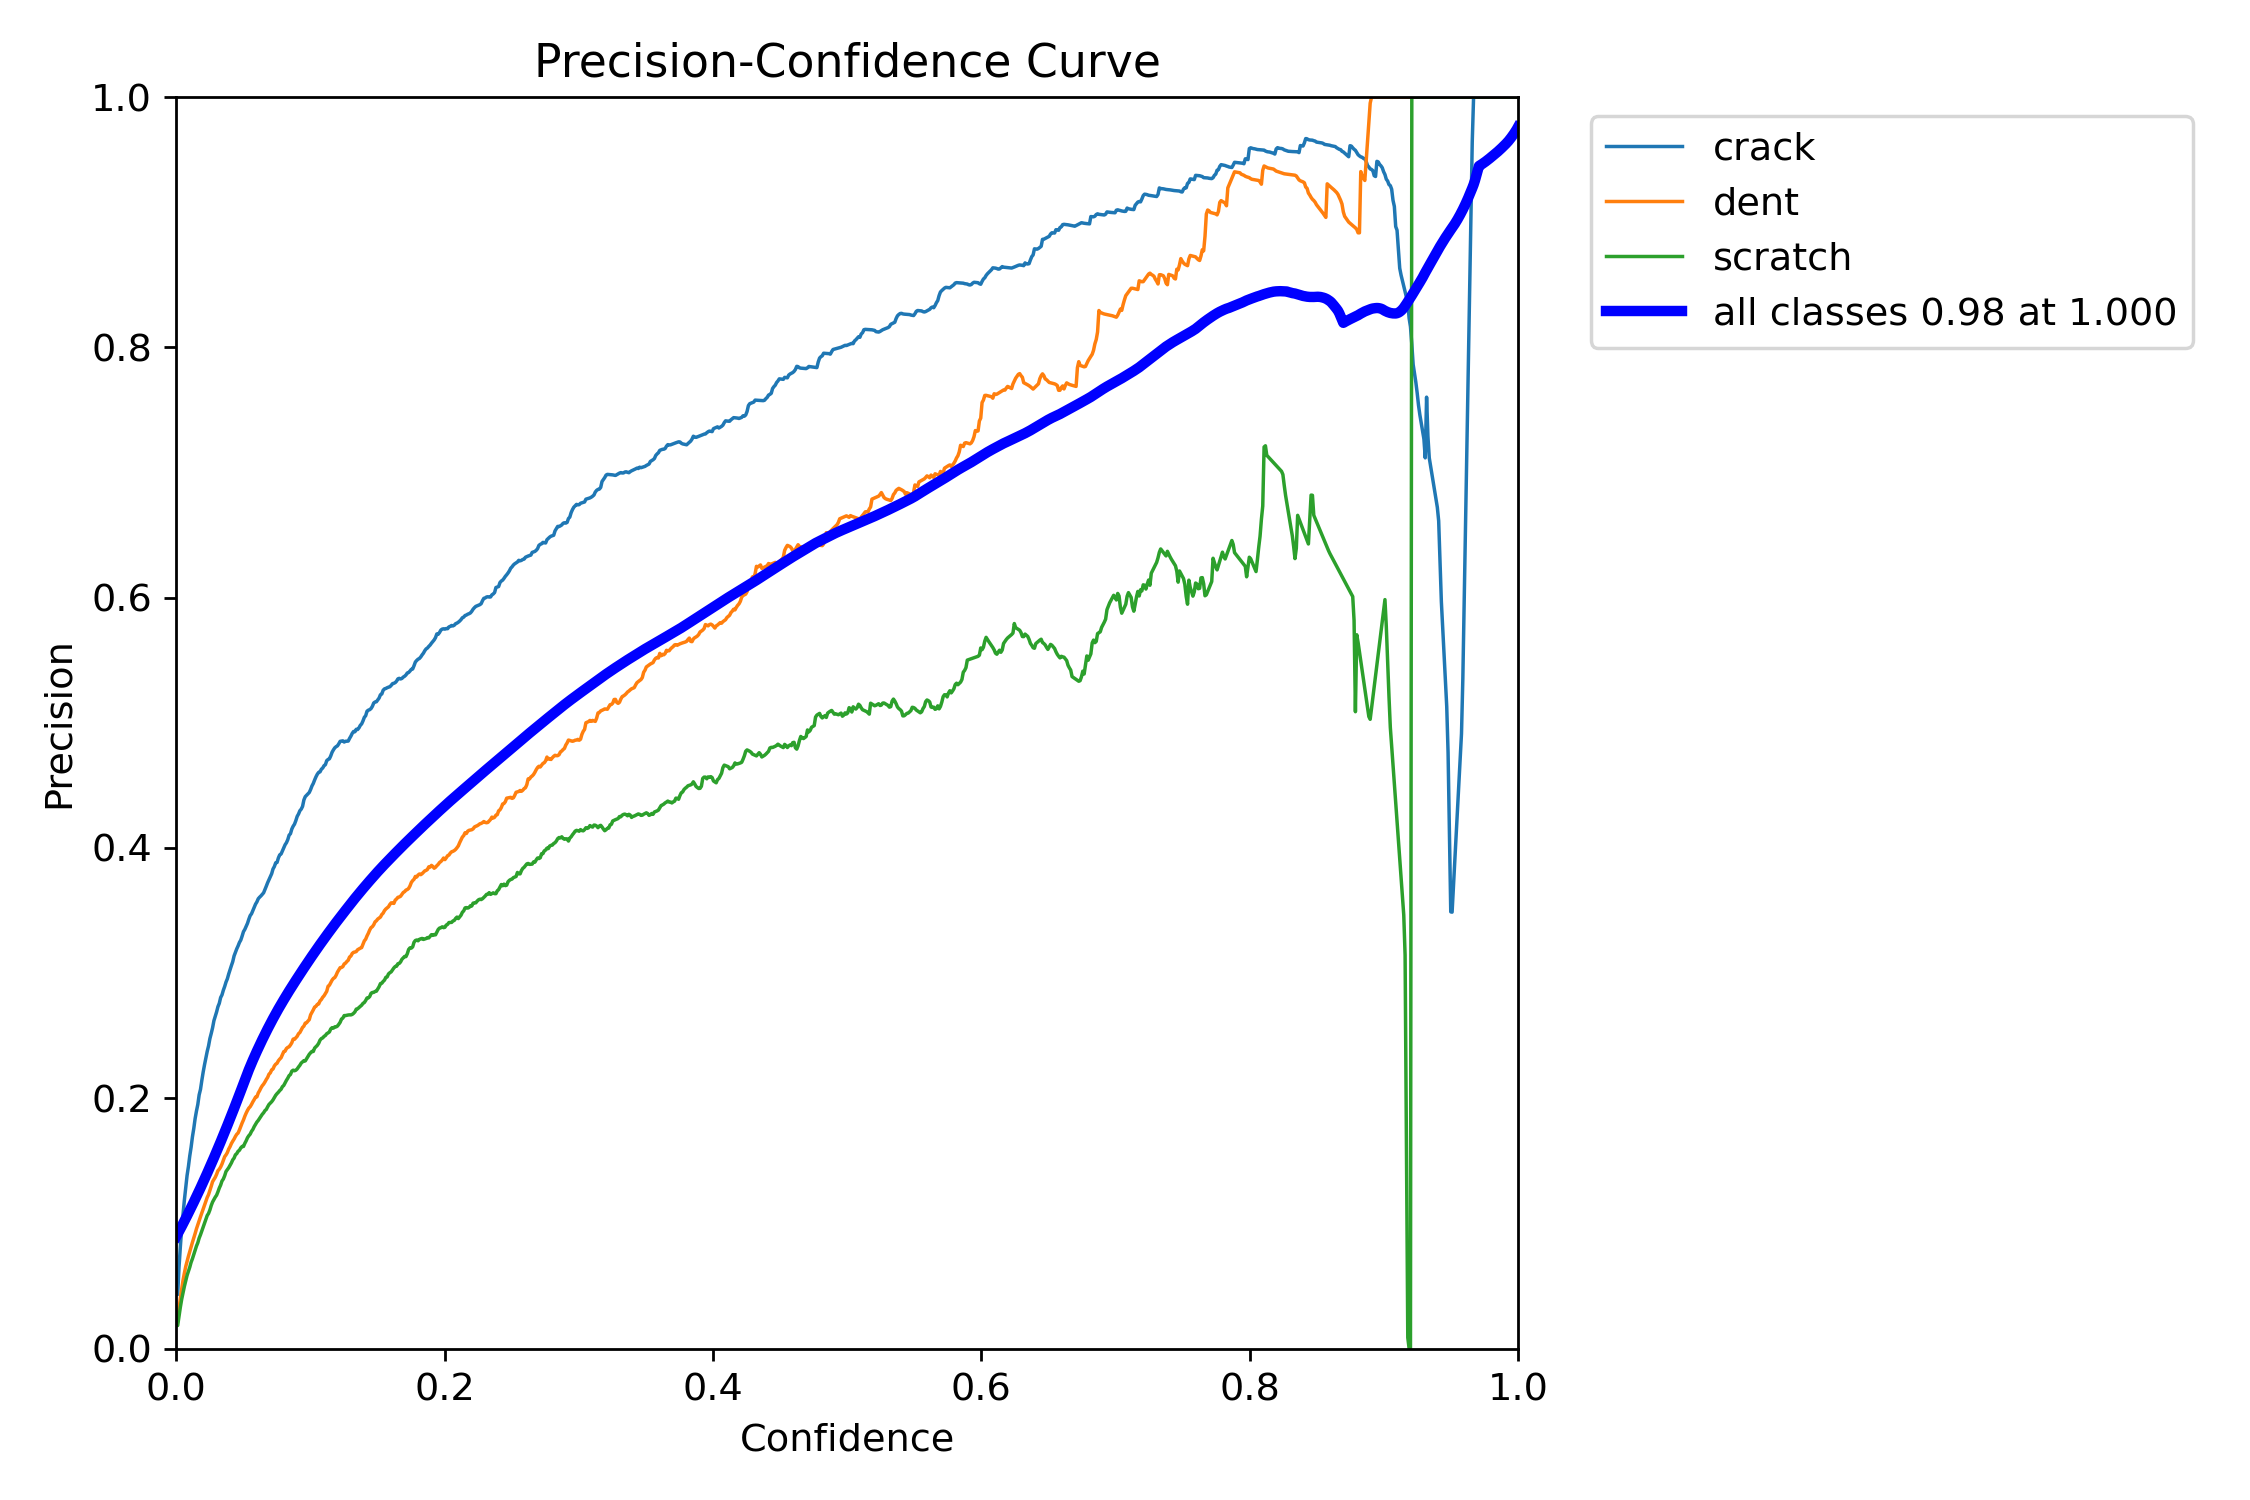


BoxR_curve.png
Esiste? True


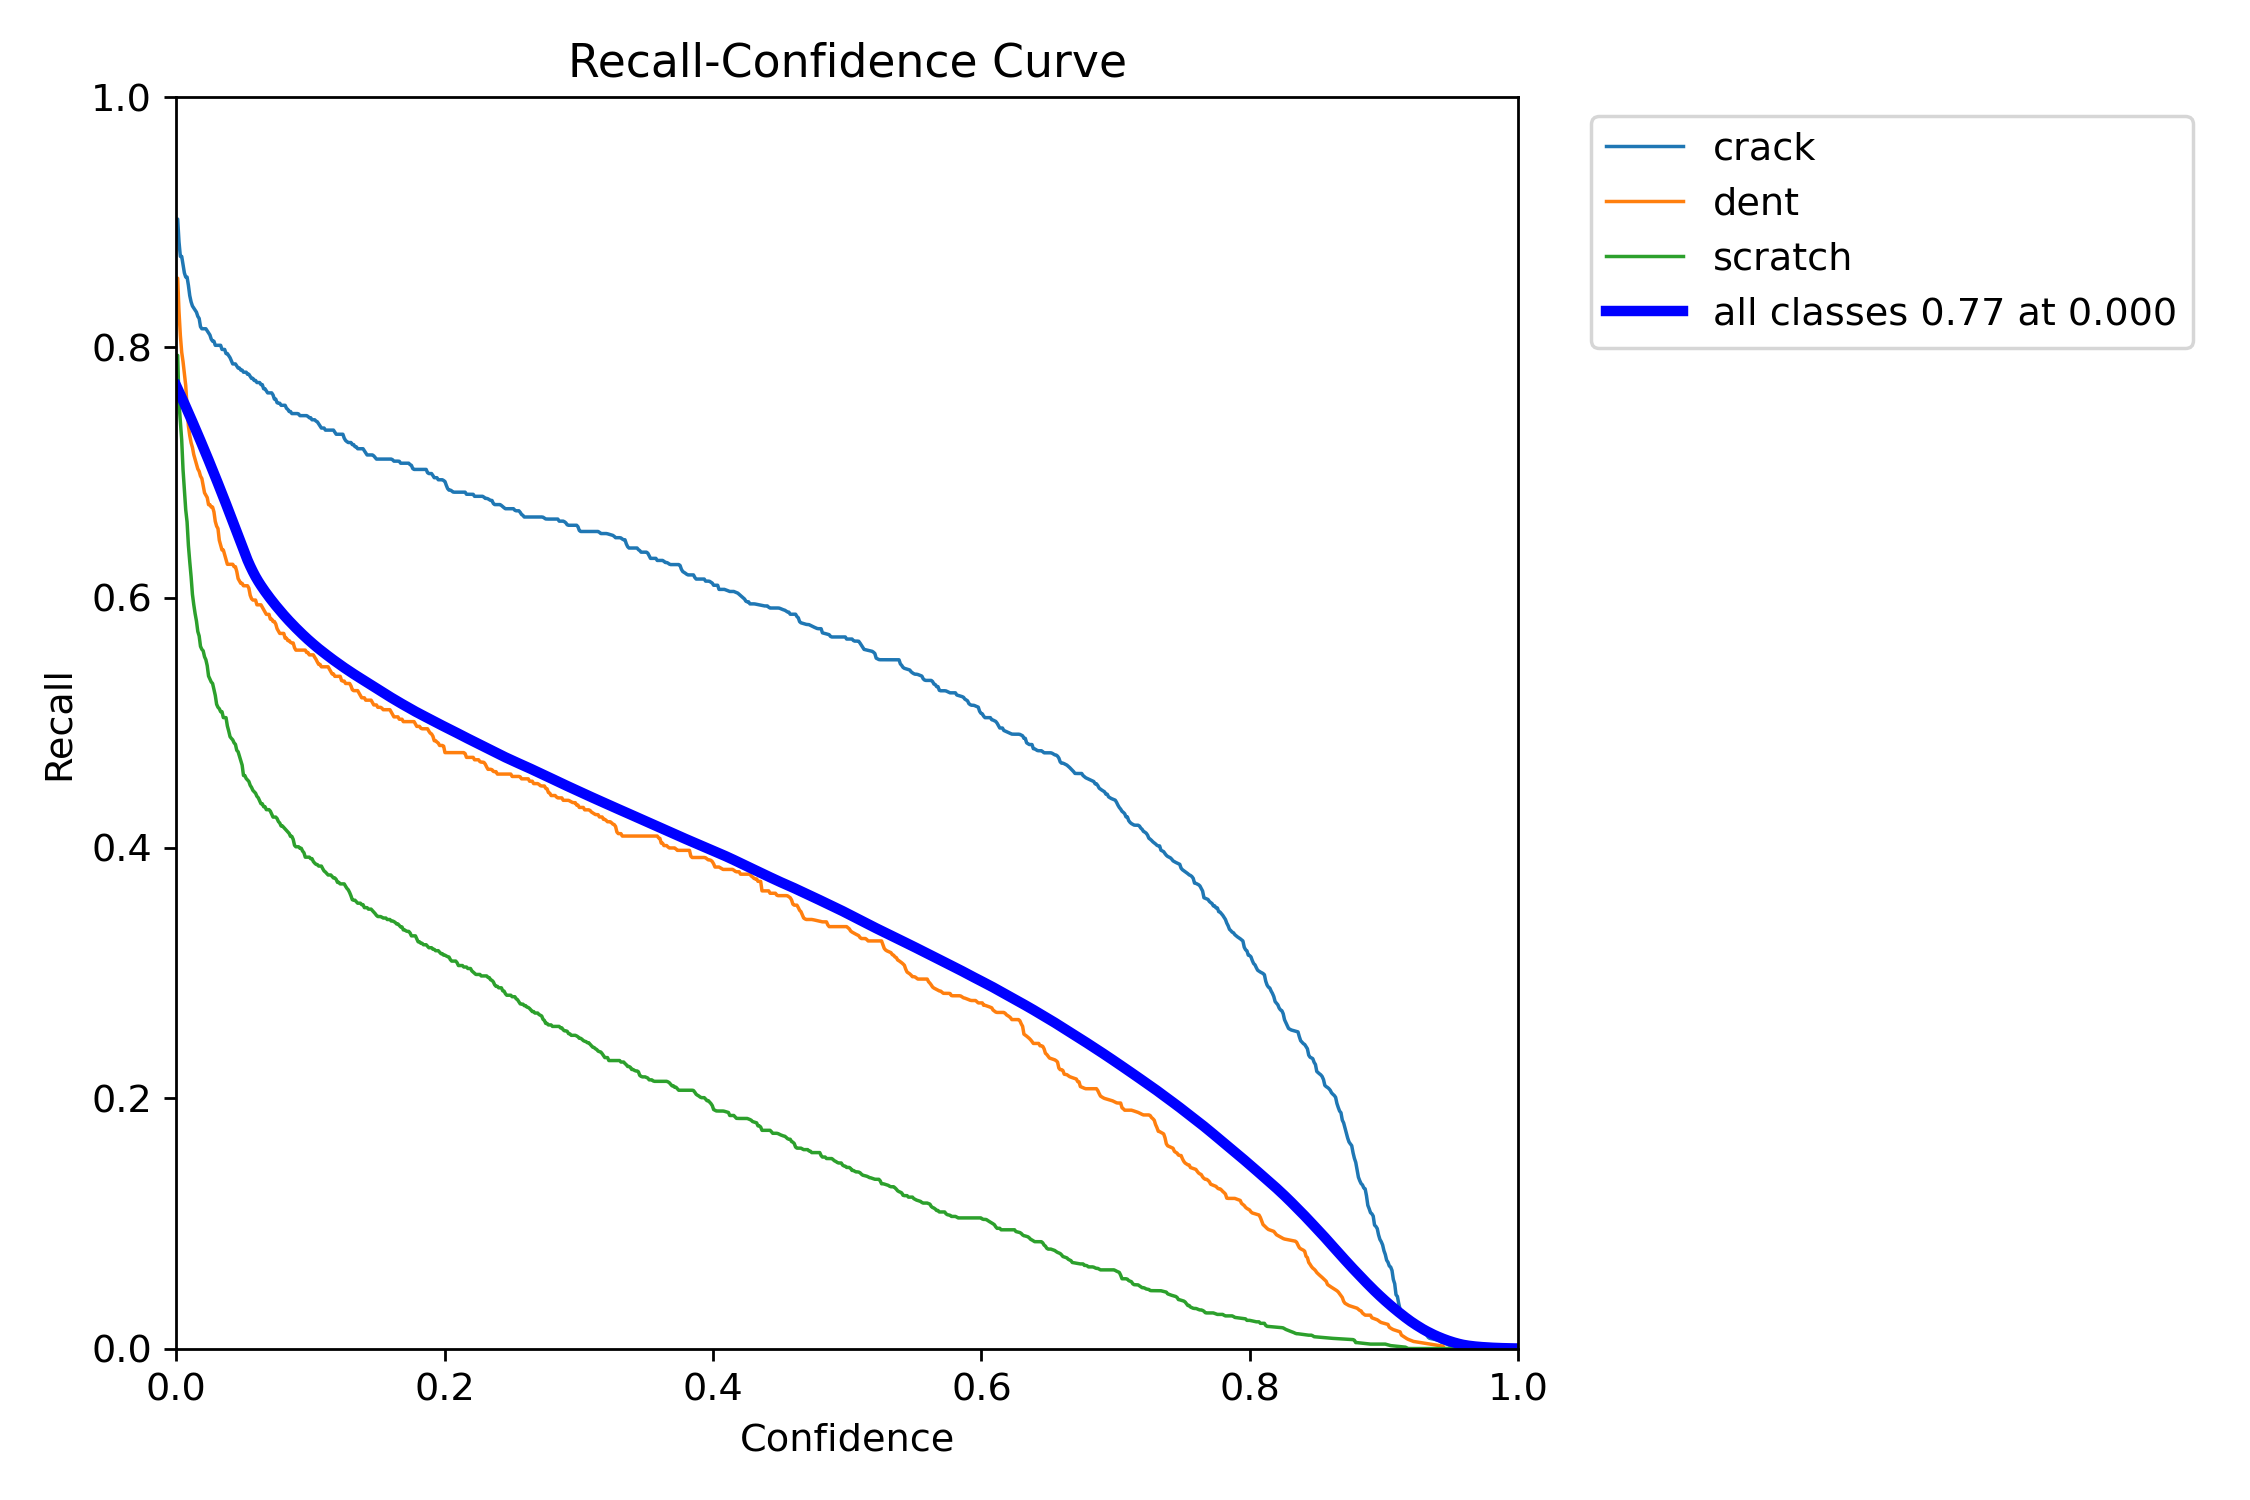


confusion_matrix.png
Esiste? True


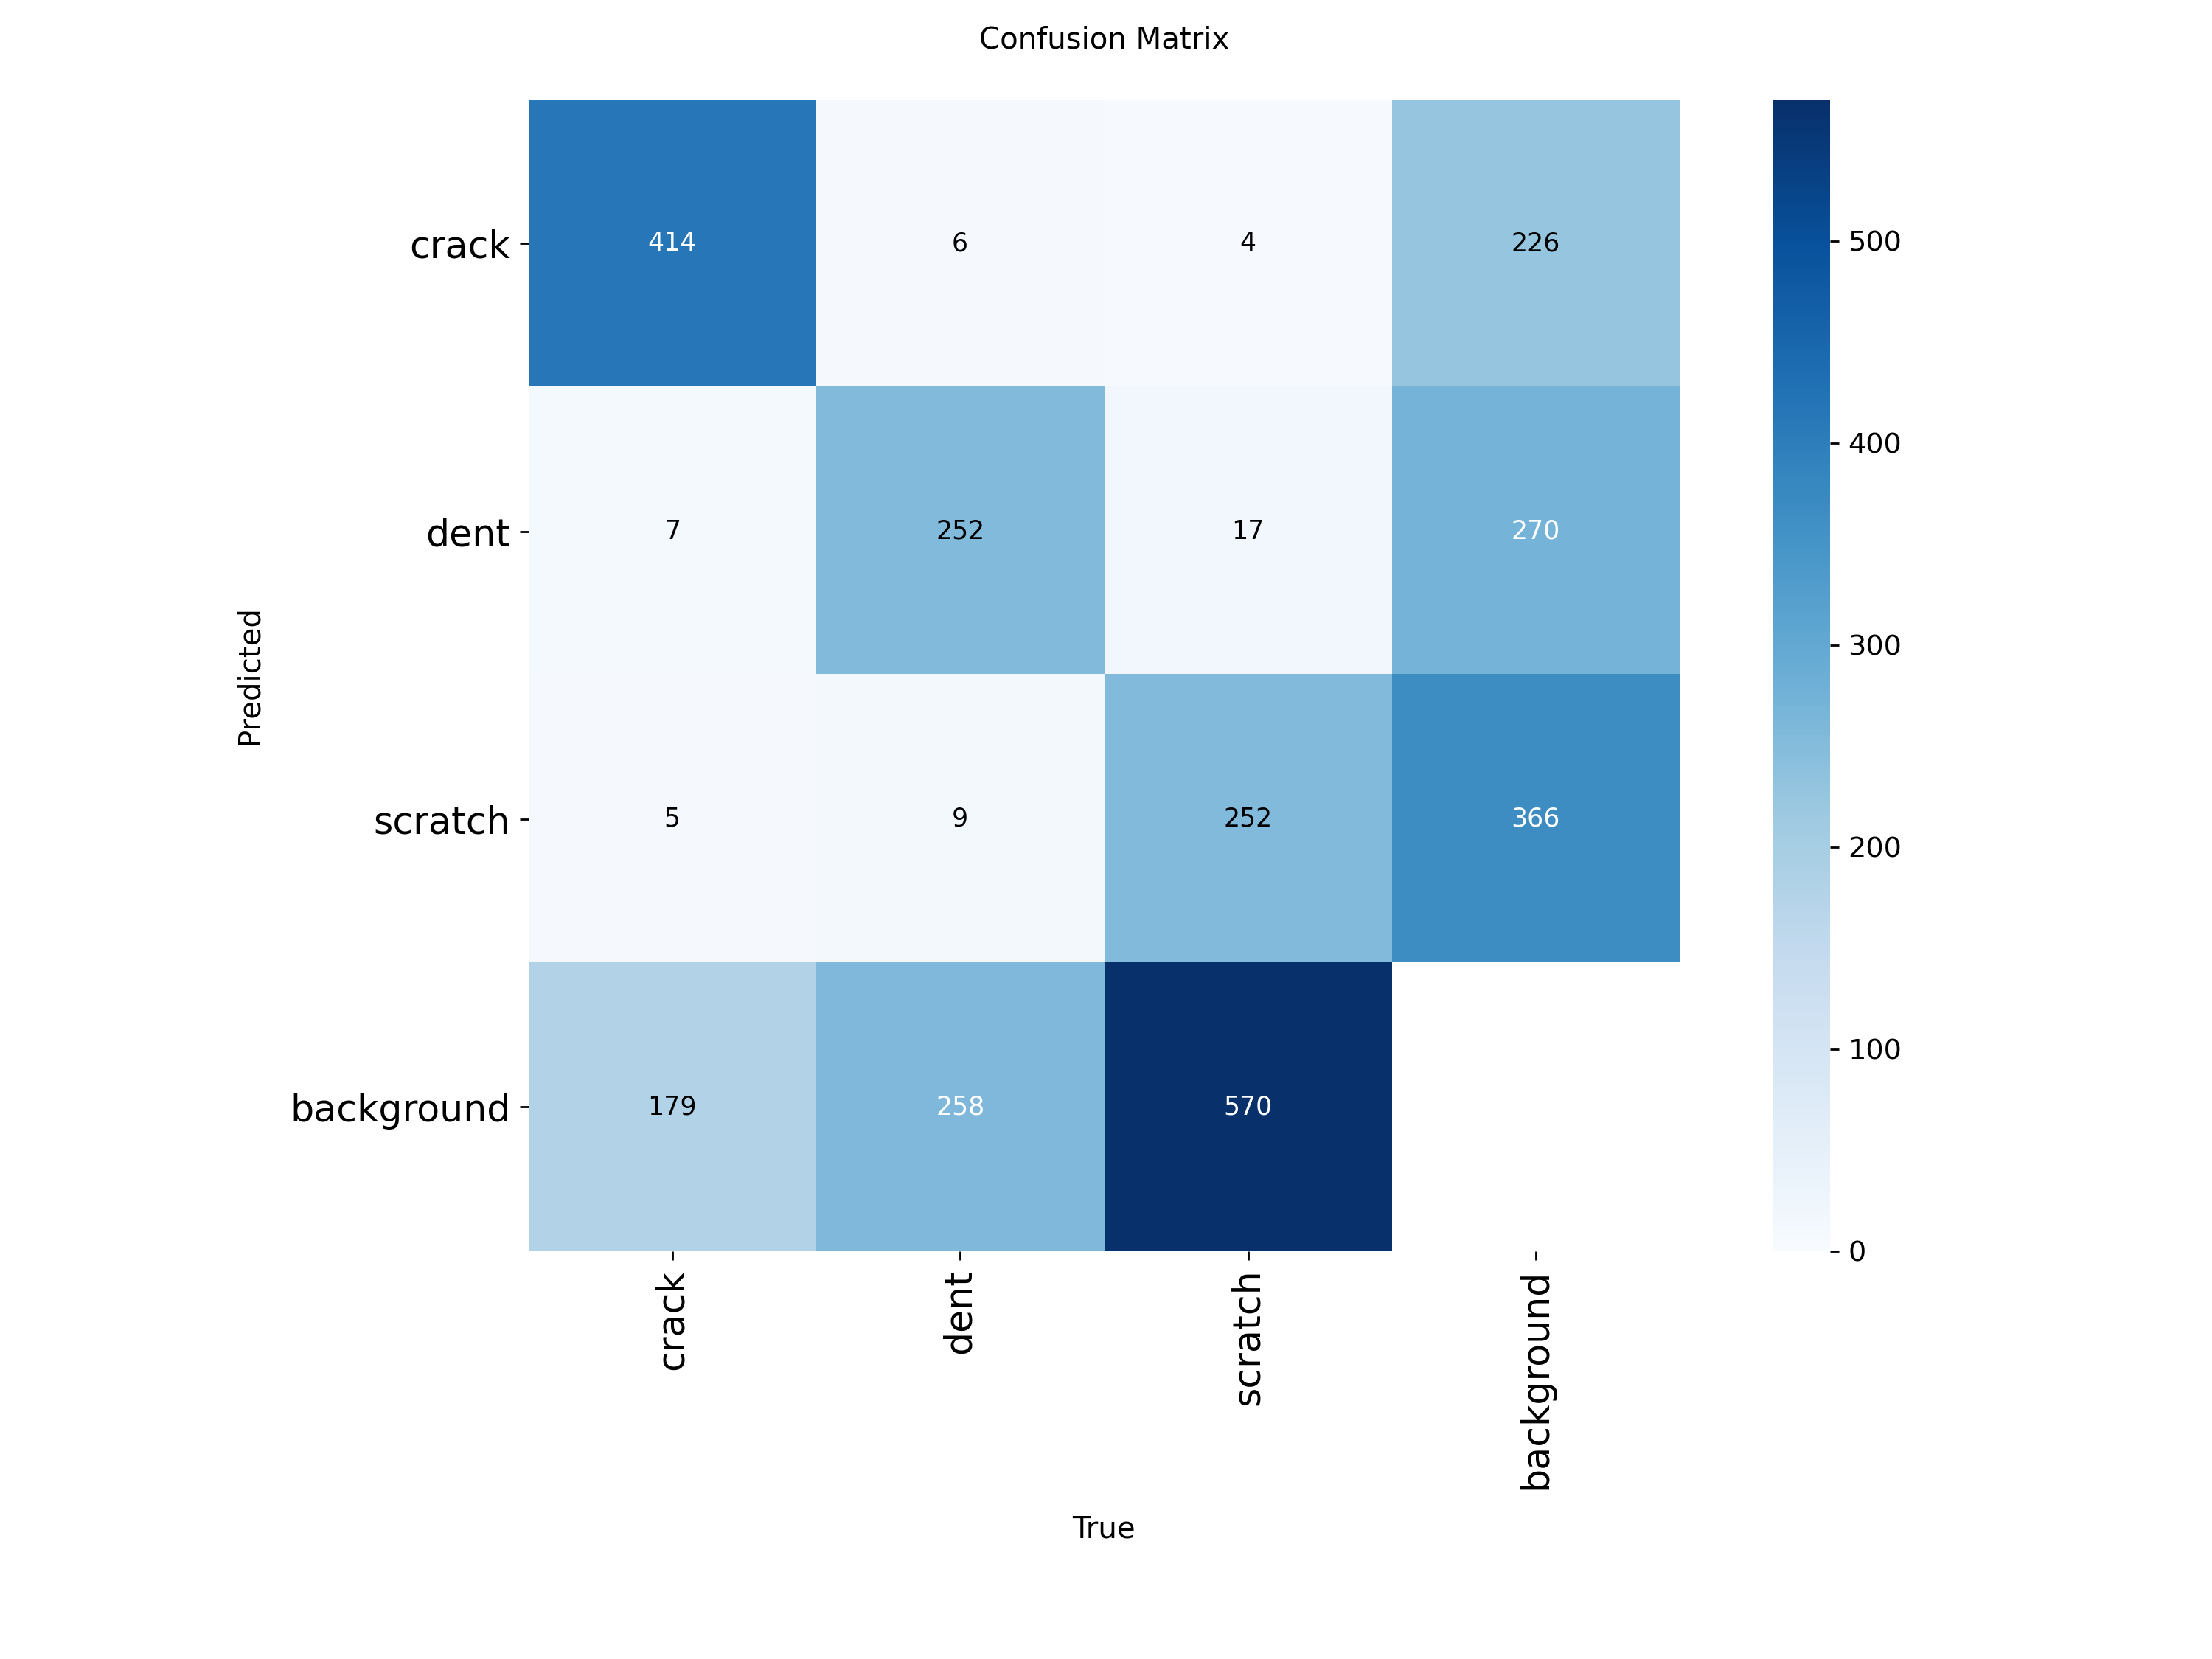


confusion_matrix_normalized.png
Esiste? True


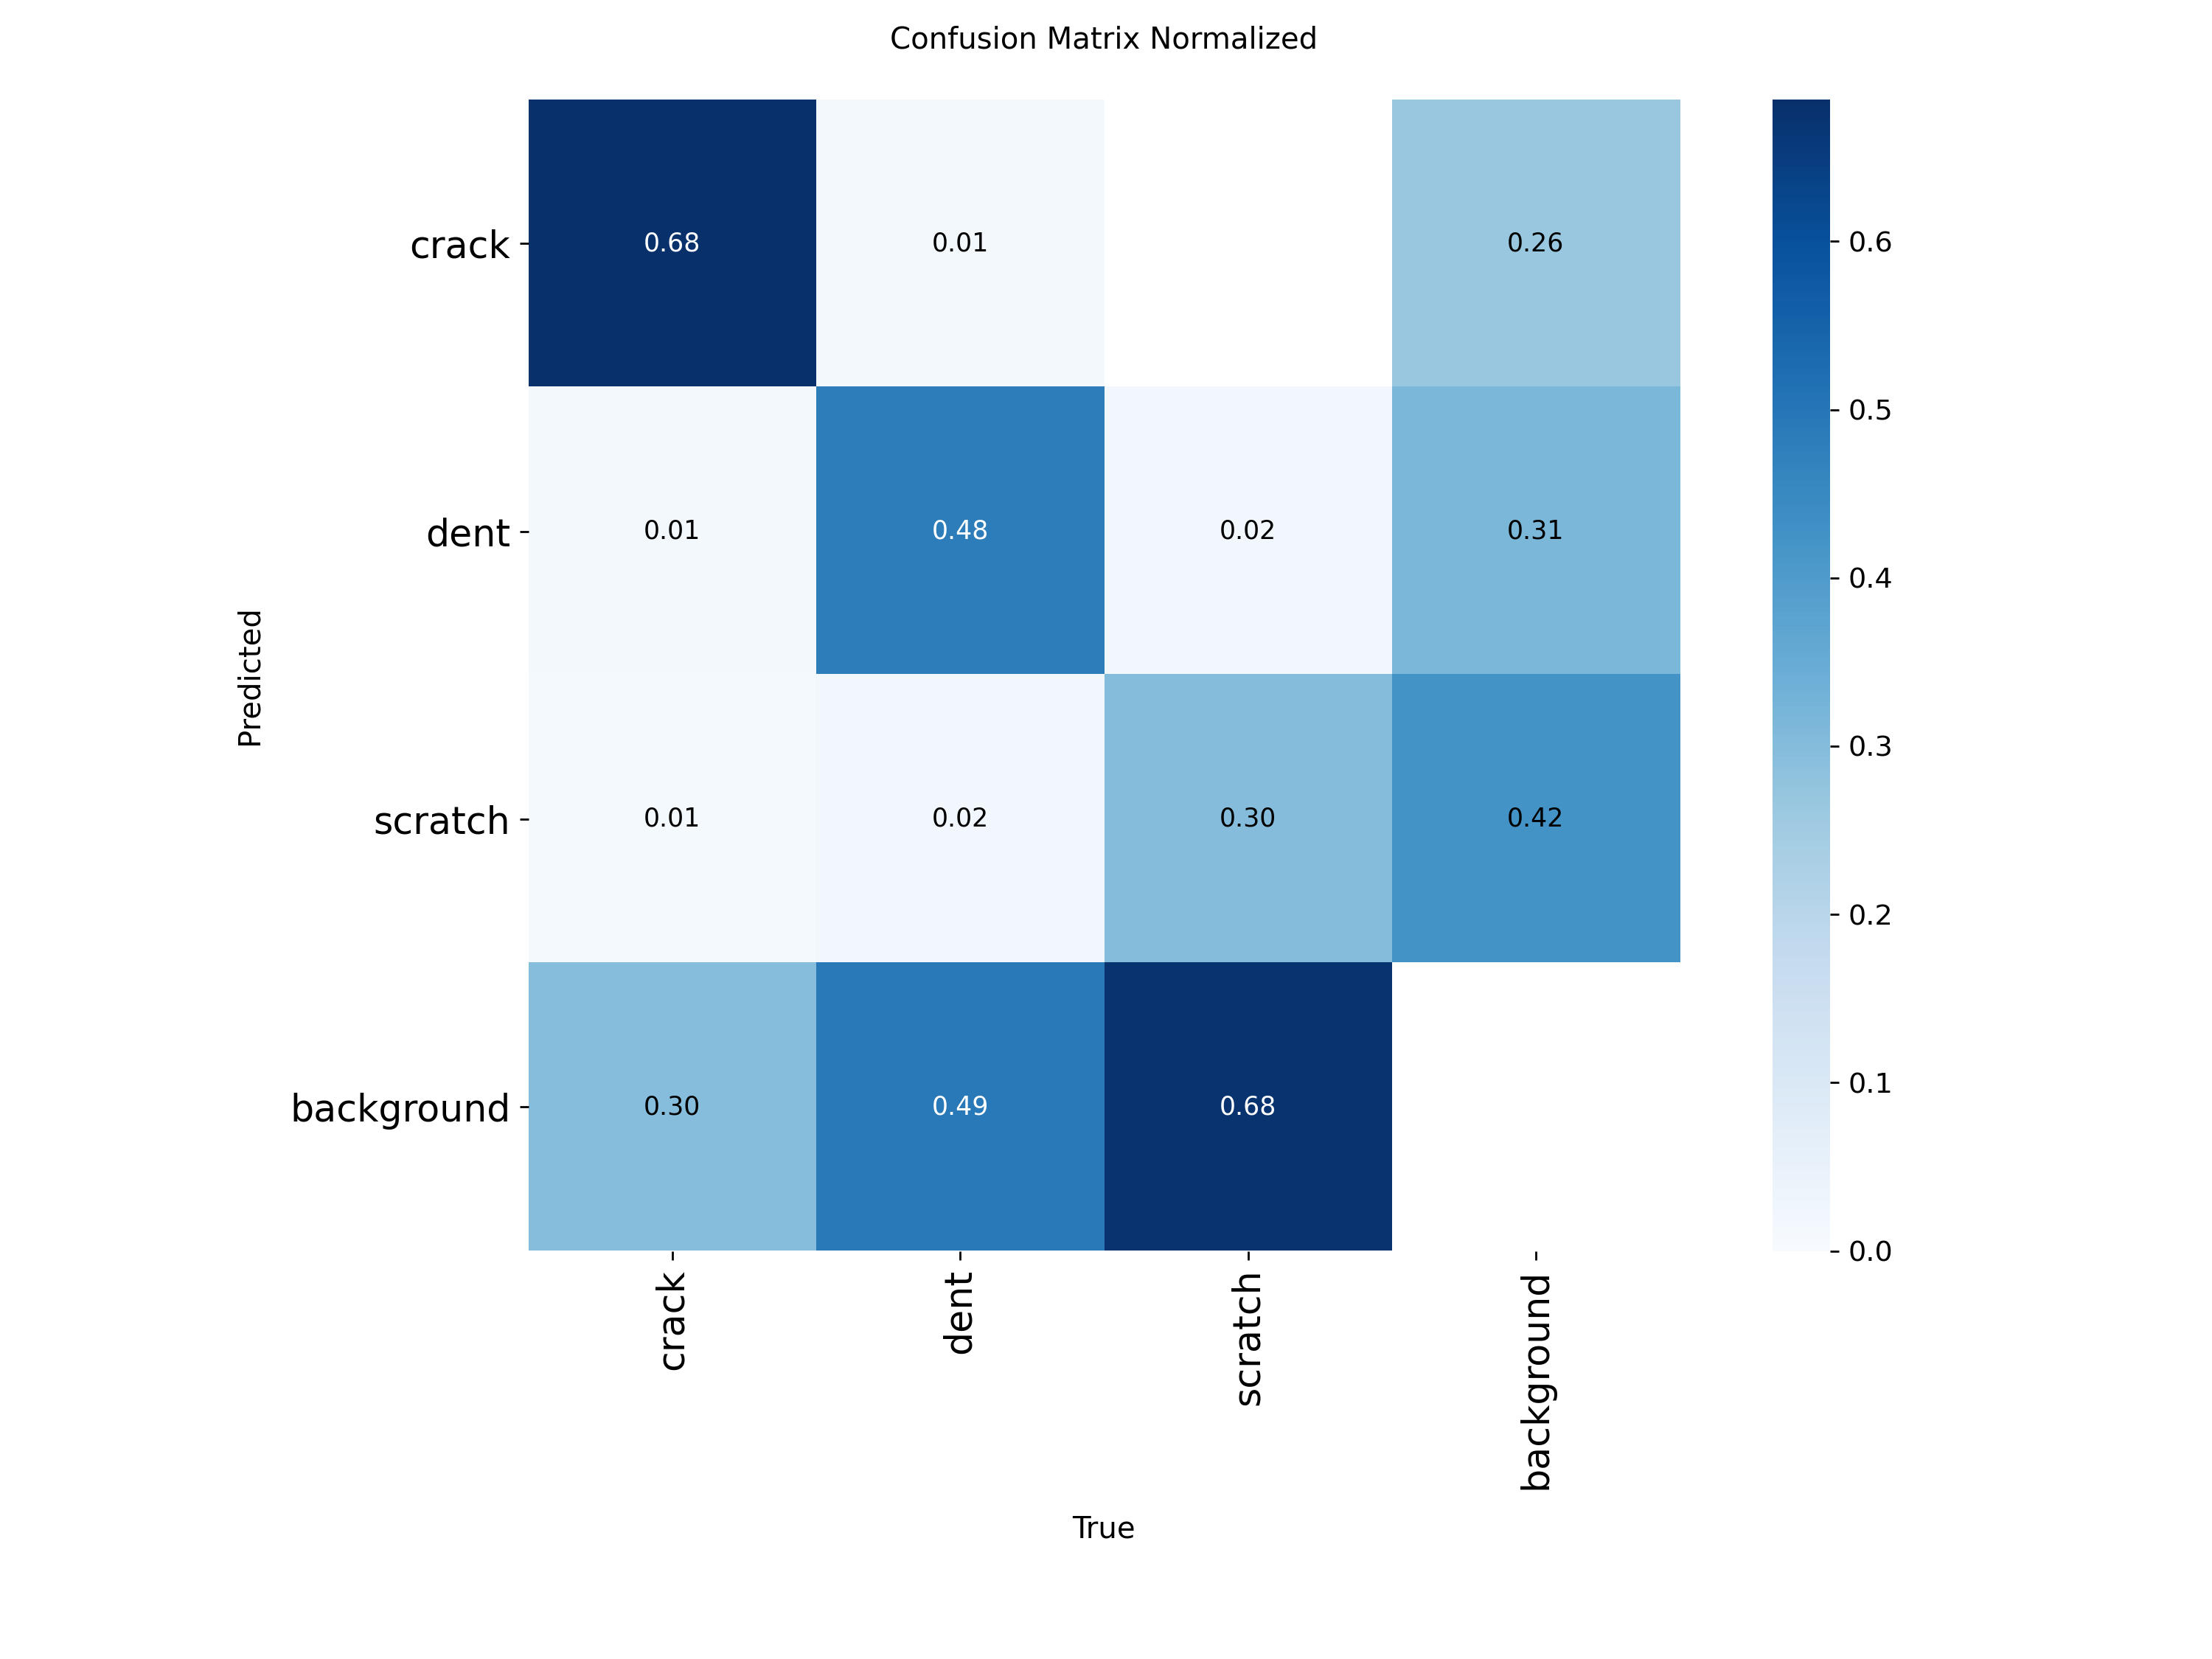

In [ ]:
from pathlib import Path
from IPython.display import Image, display

VAL_PLOTS_DIR = Path(DRIVE_PROJECT_DIR) / (RUN_NAME + "_val_plots")

files_to_show = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png"
]

for file_name in files_to_show:
    file_path = VAL_PLOTS_DIR / file_name

    print("\n" + "="*80)
    print(file_name)
    print("Esiste?", file_path.exists())

    if file_path.exists():
        display(Image(filename=str(file_path), width=900))
    else:
        print("File non trovato:", file_path)

#8.3 Visualizzazione grafici del training


results.png
Esiste? True


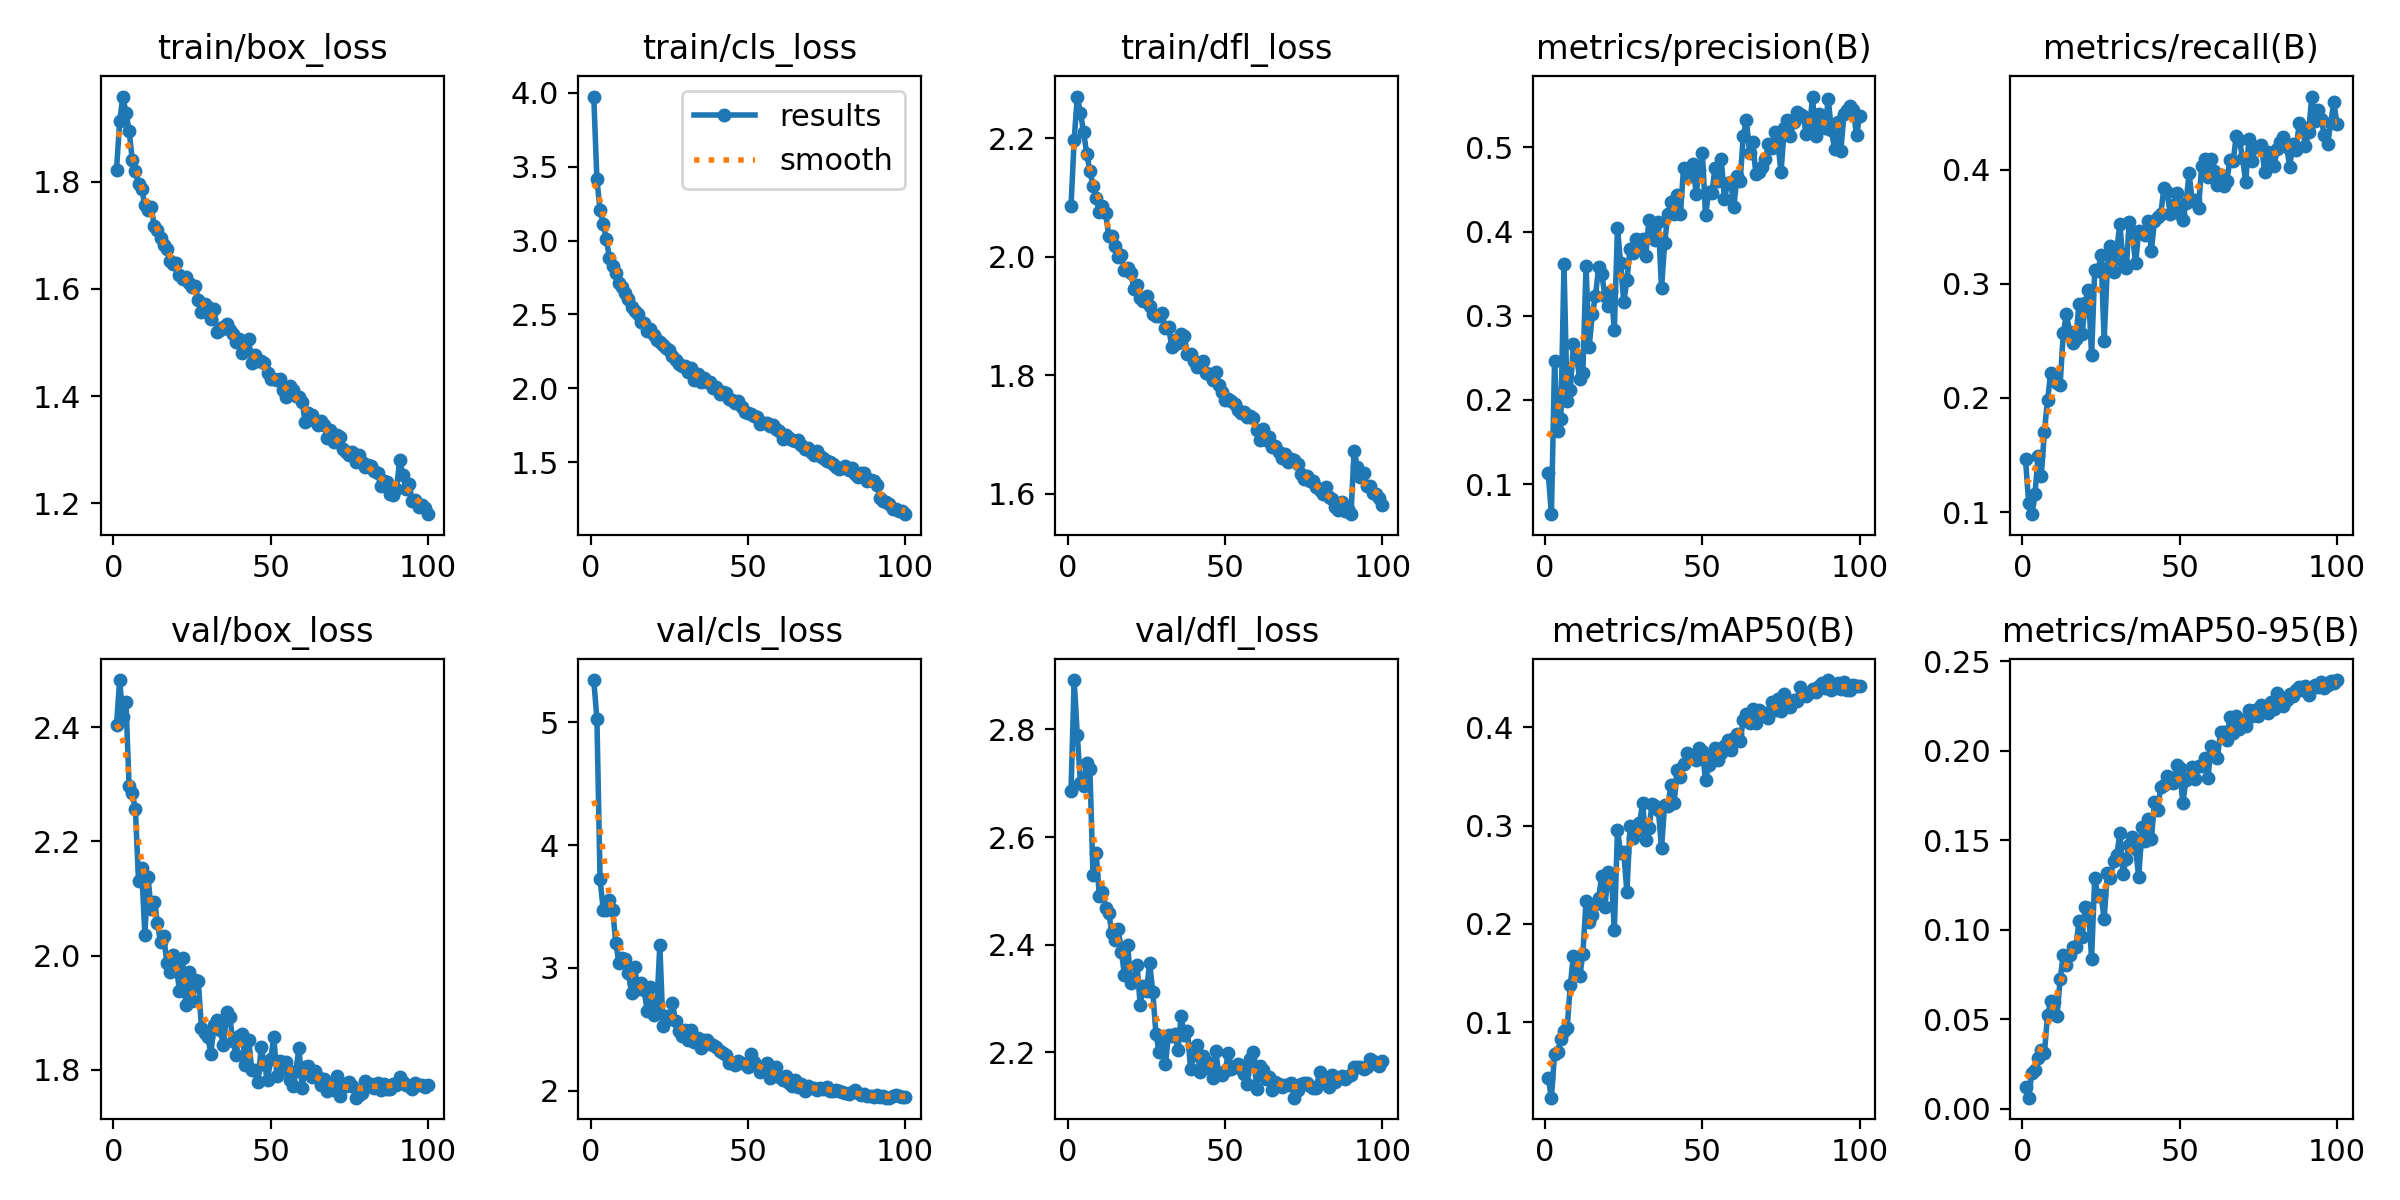


labels.jpg
Esiste? True


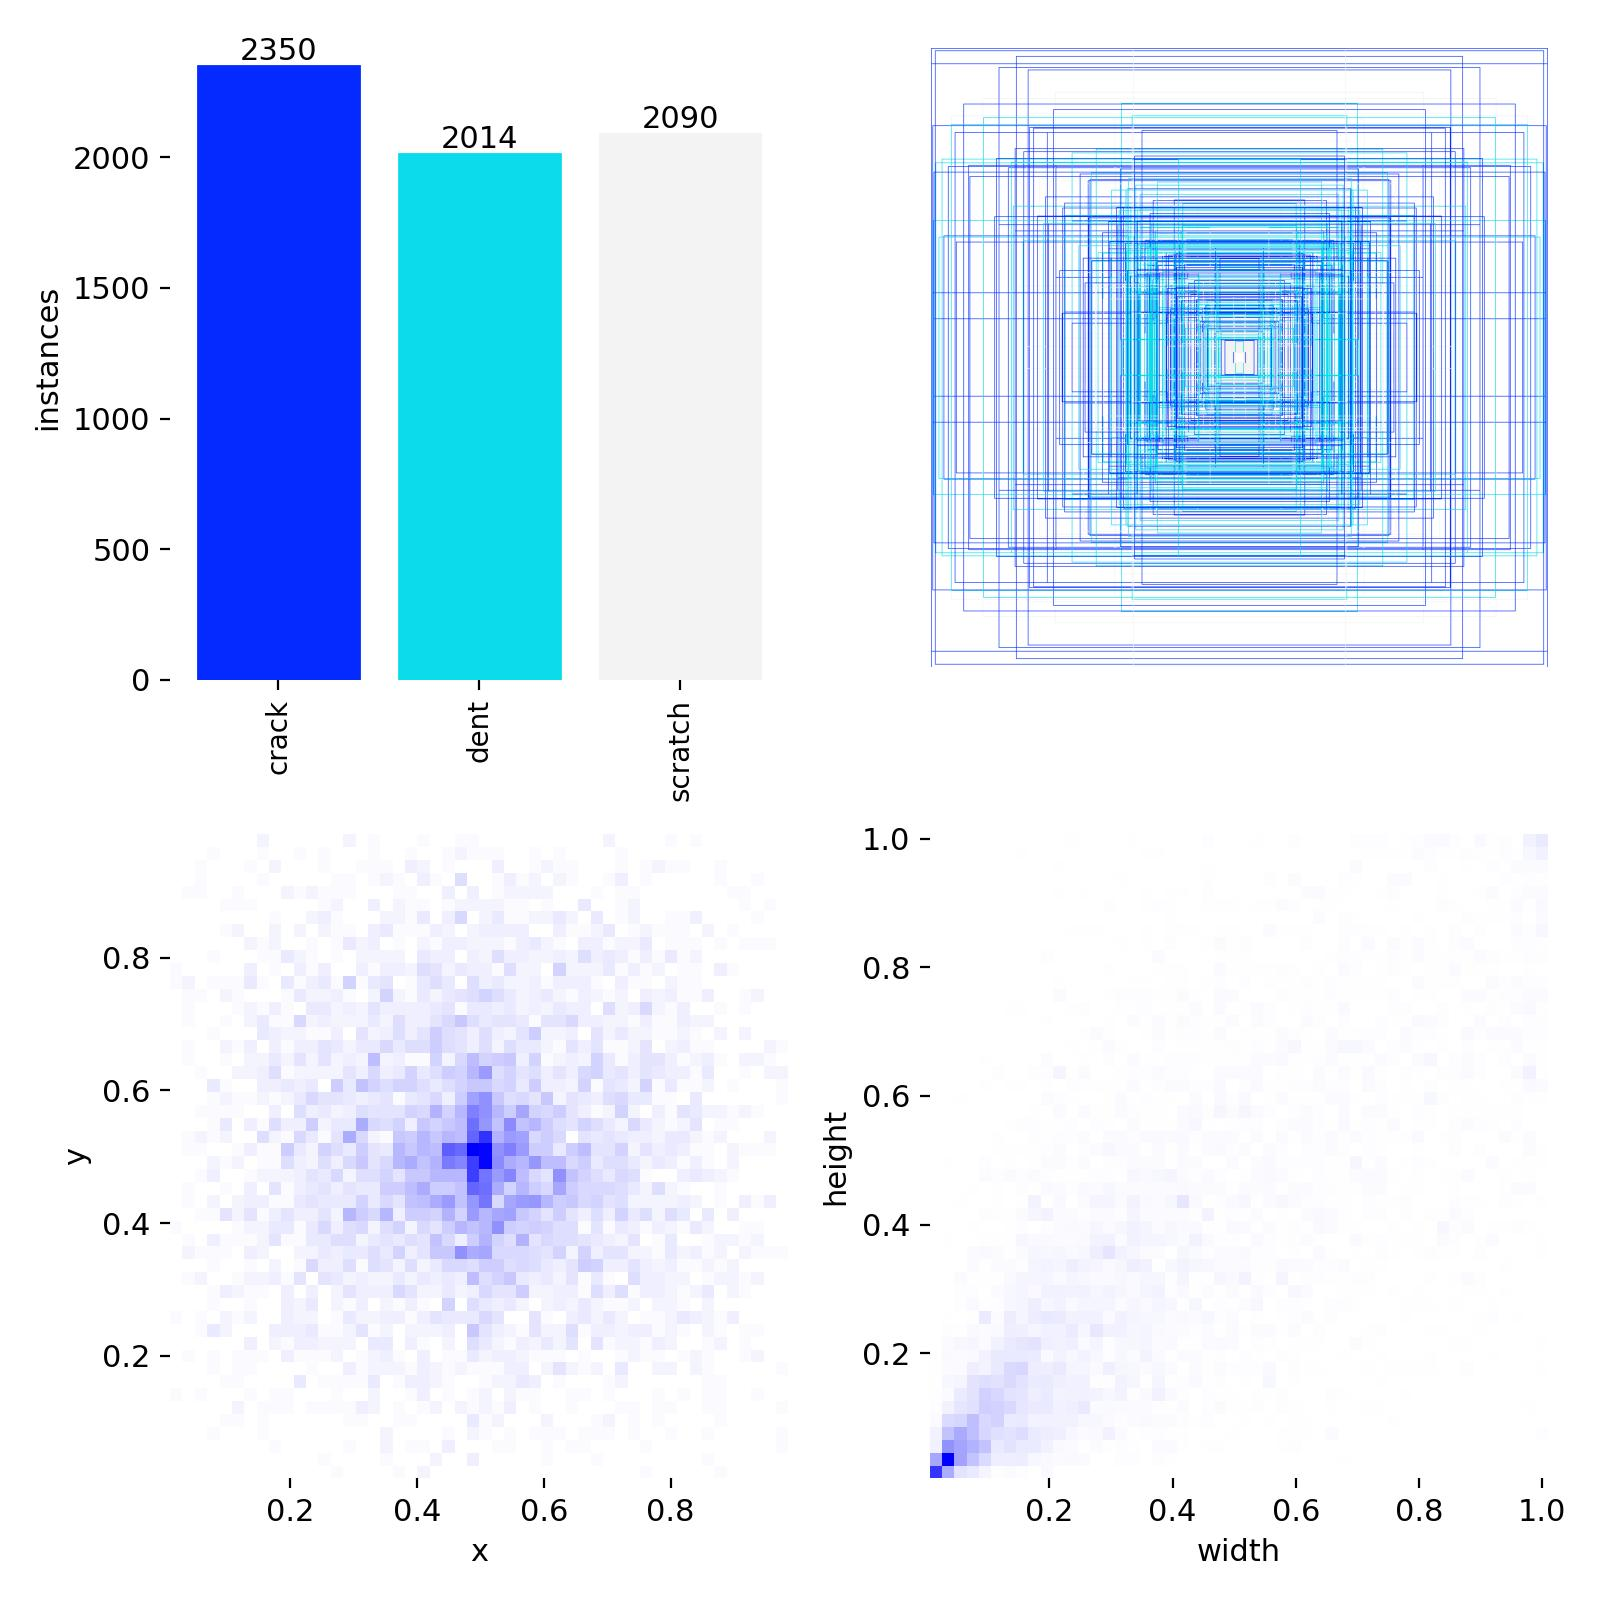


confusion_matrix.png
Esiste? True


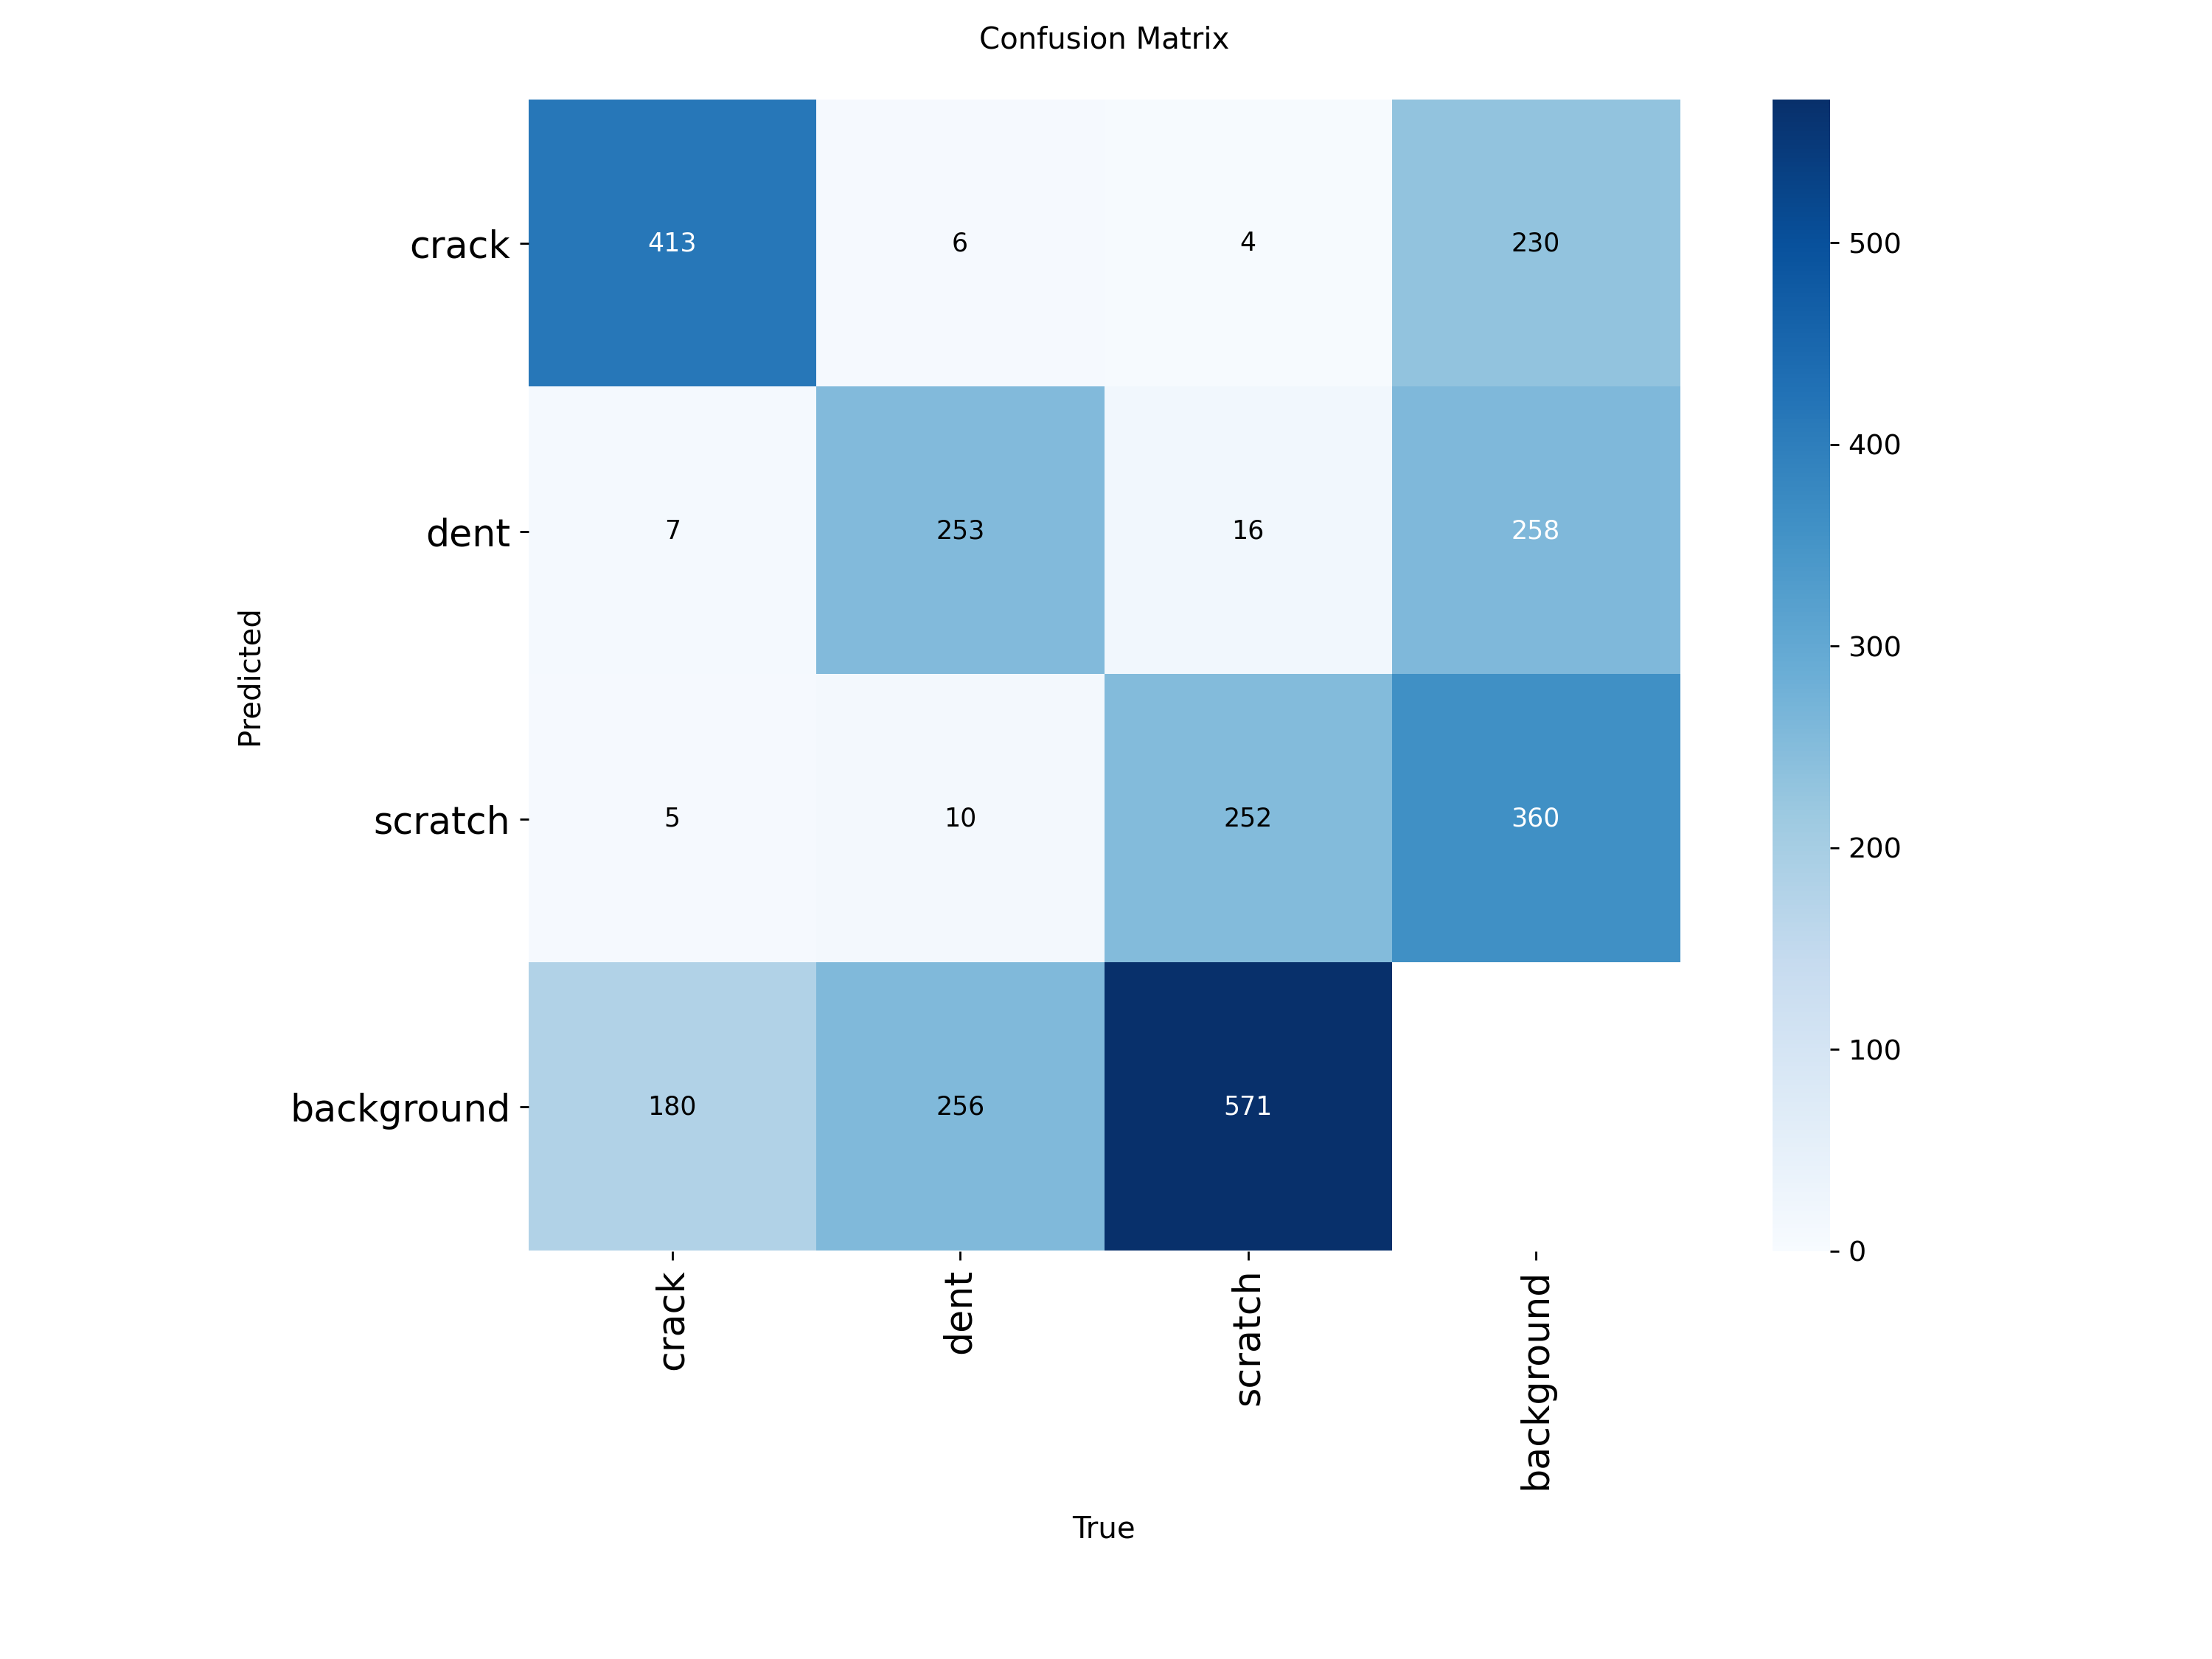


confusion_matrix_normalized.png
Esiste? True


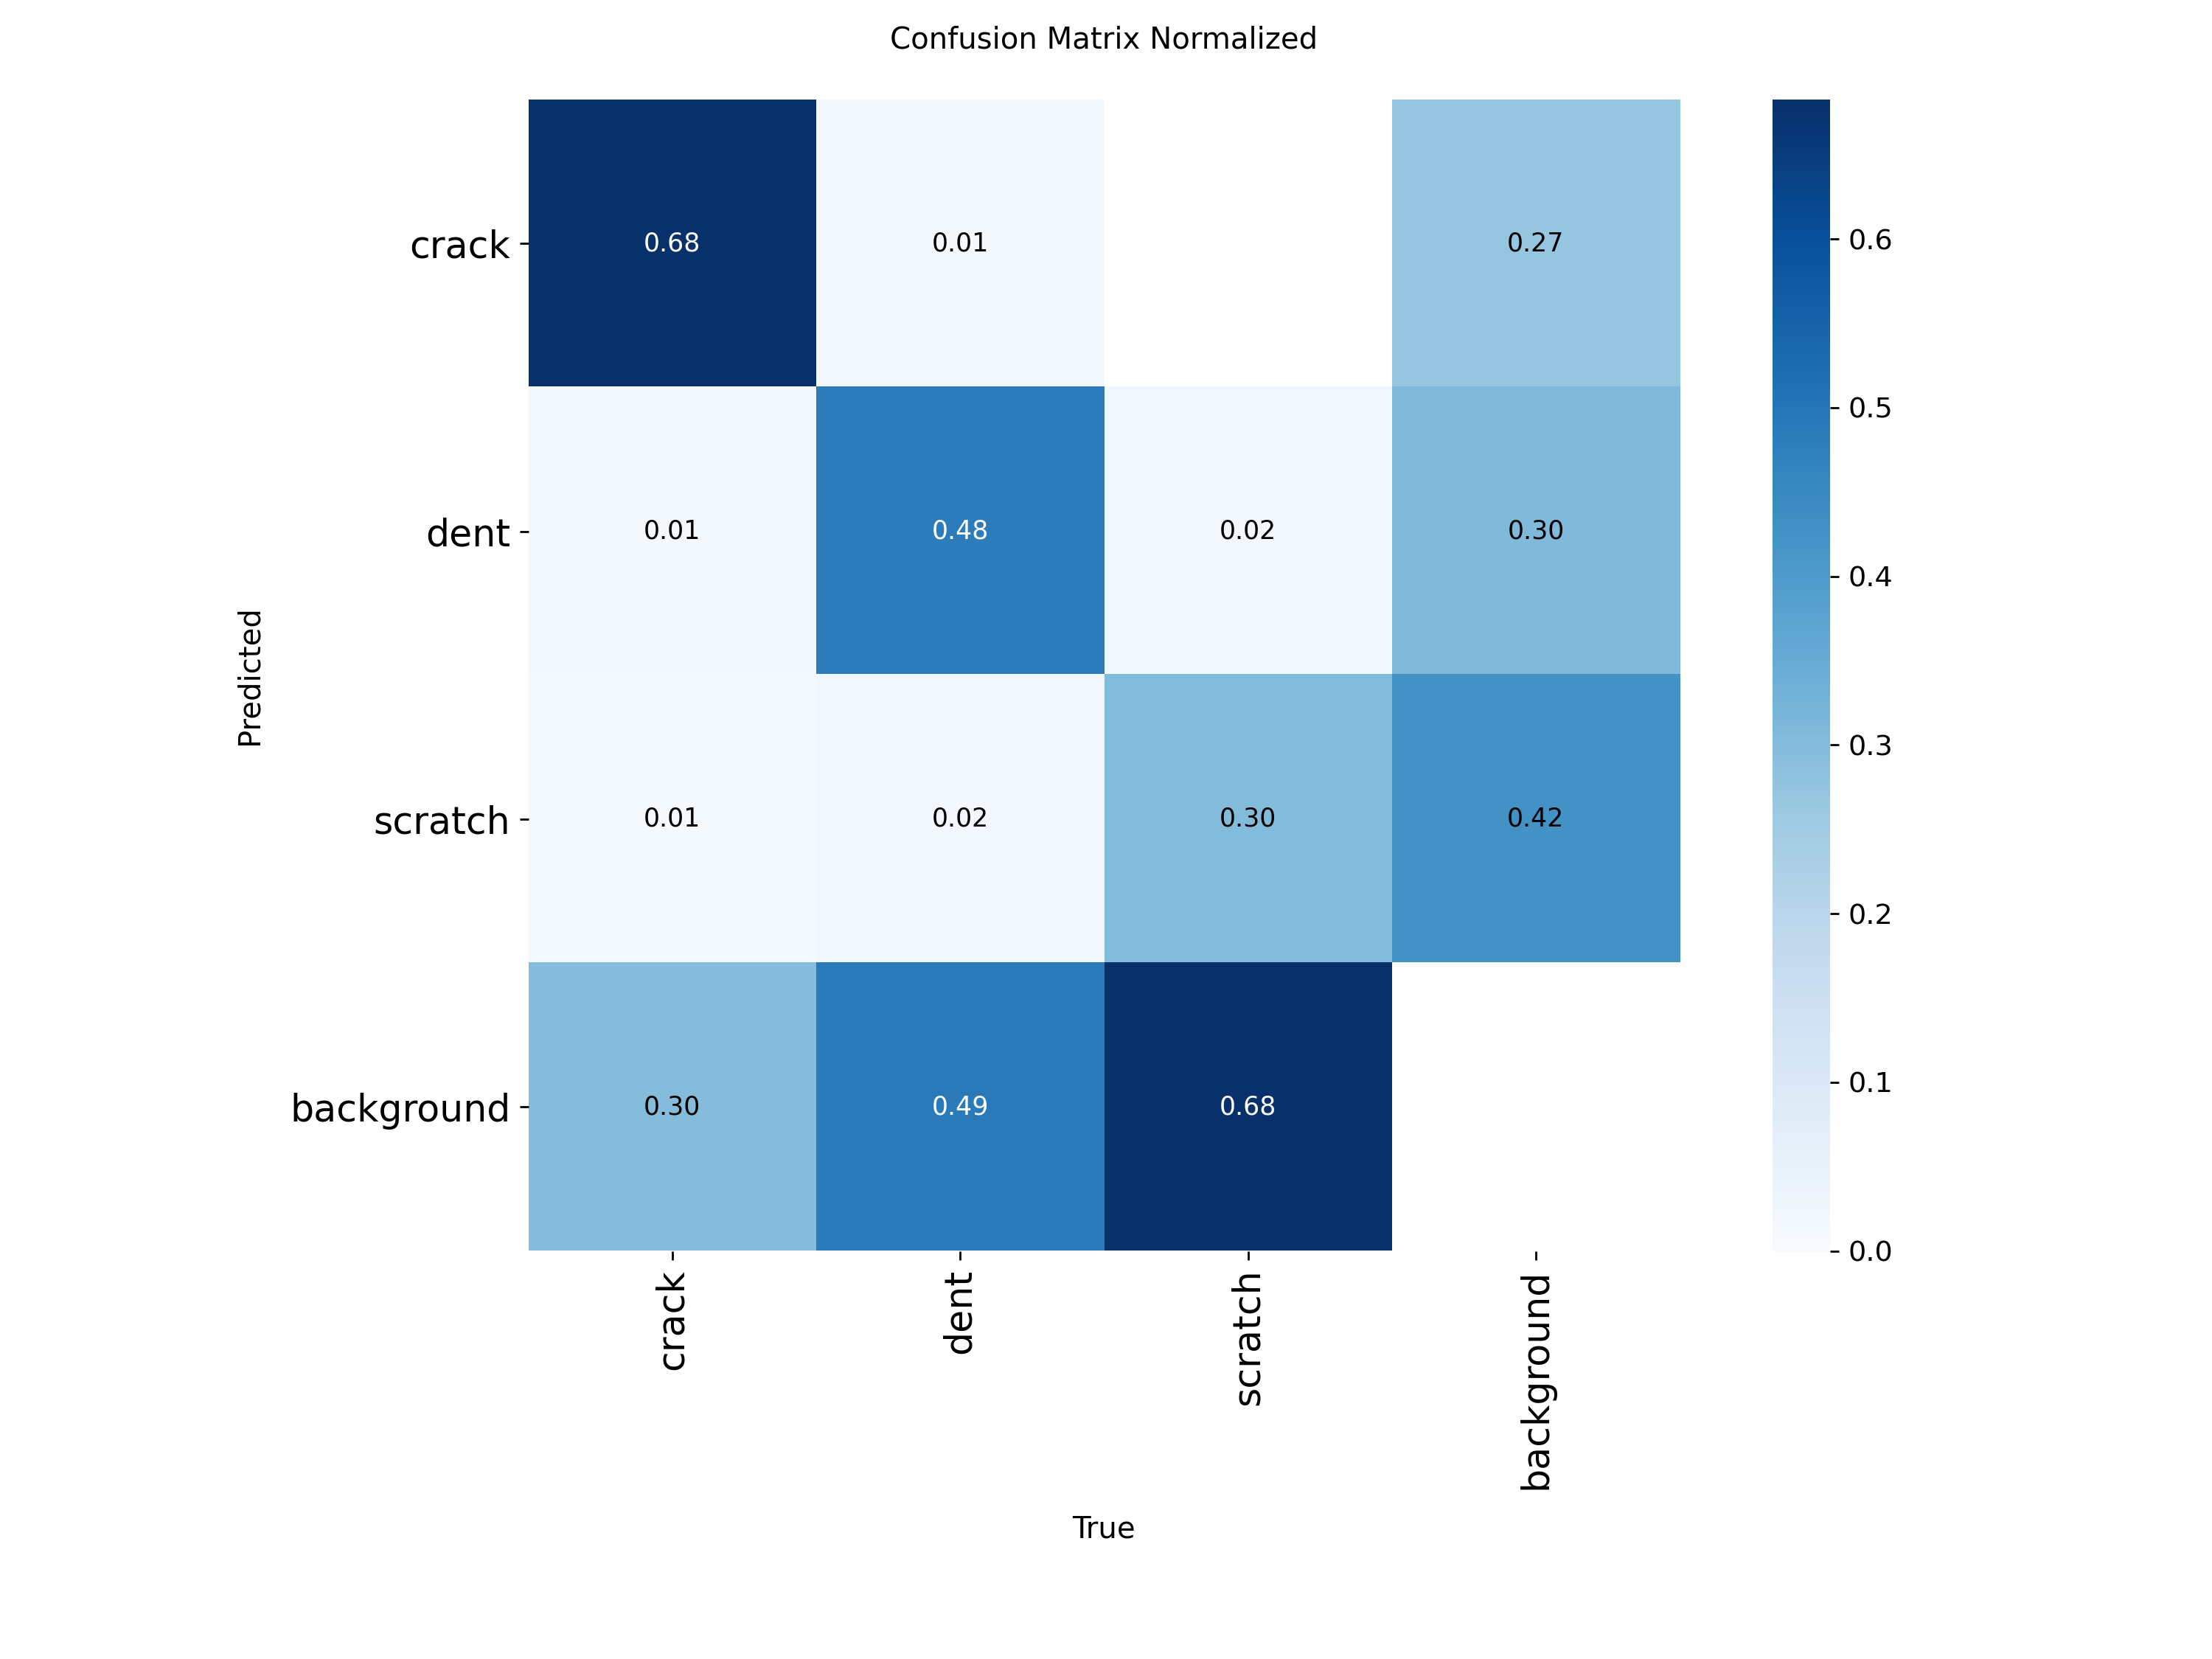


BoxPR_curve.png
Esiste? True


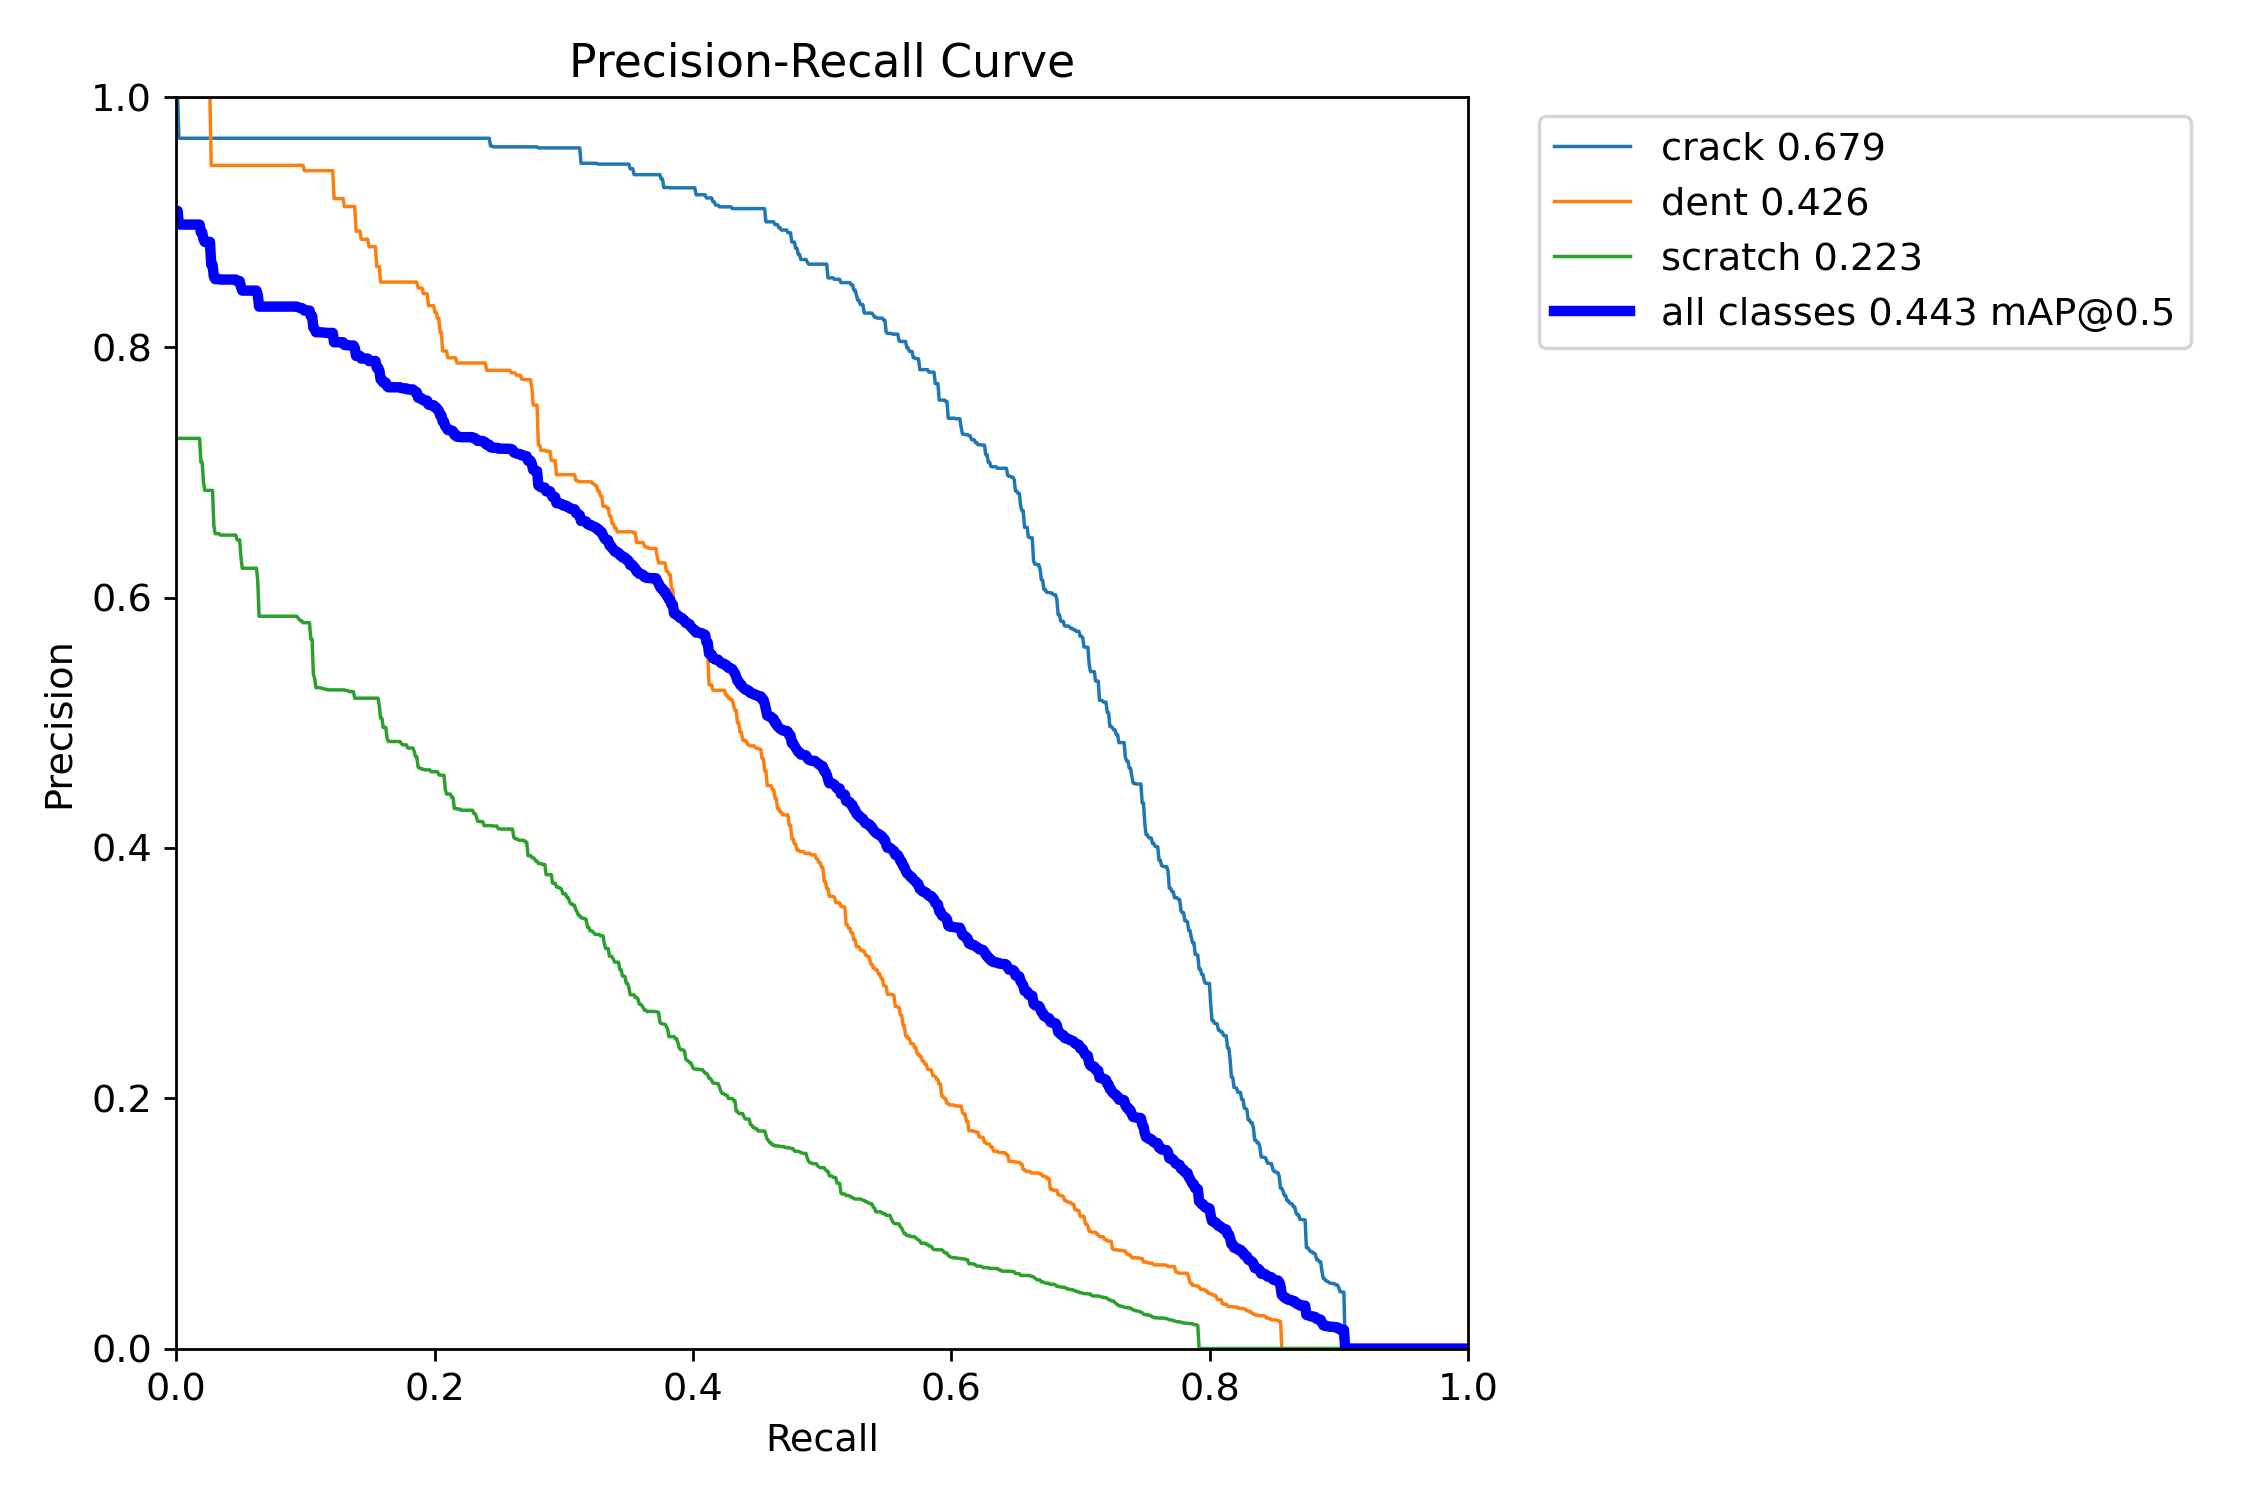


BoxF1_curve.png
Esiste? True


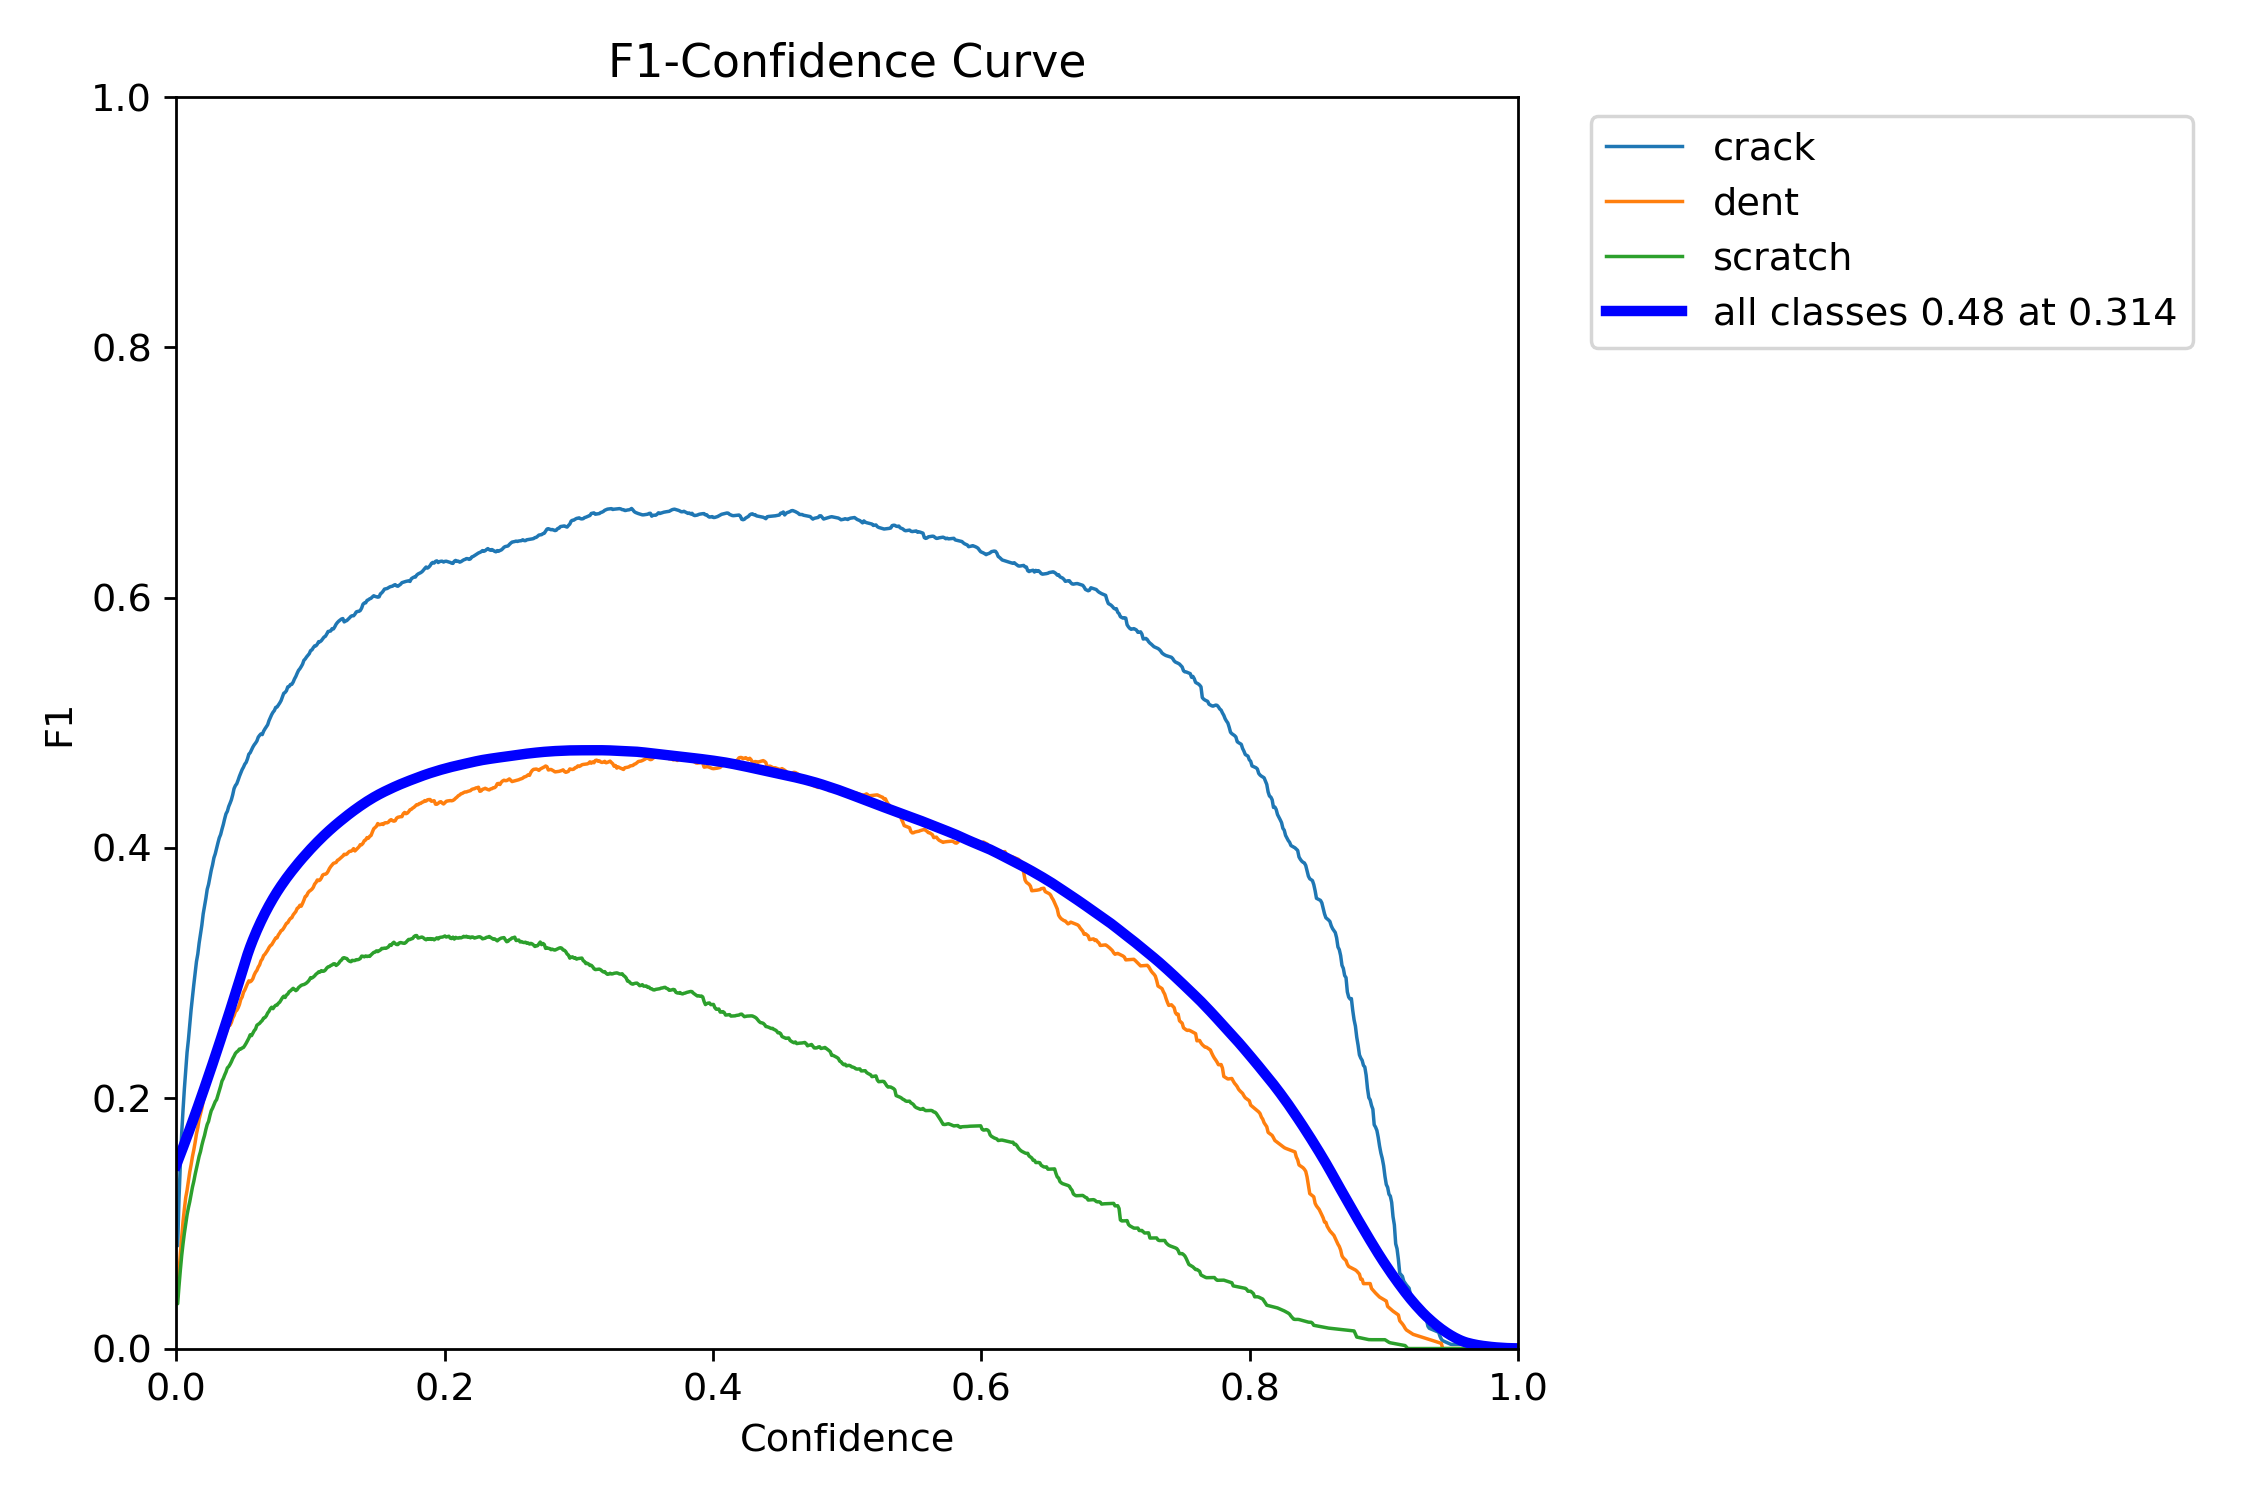


BoxP_curve.png
Esiste? True


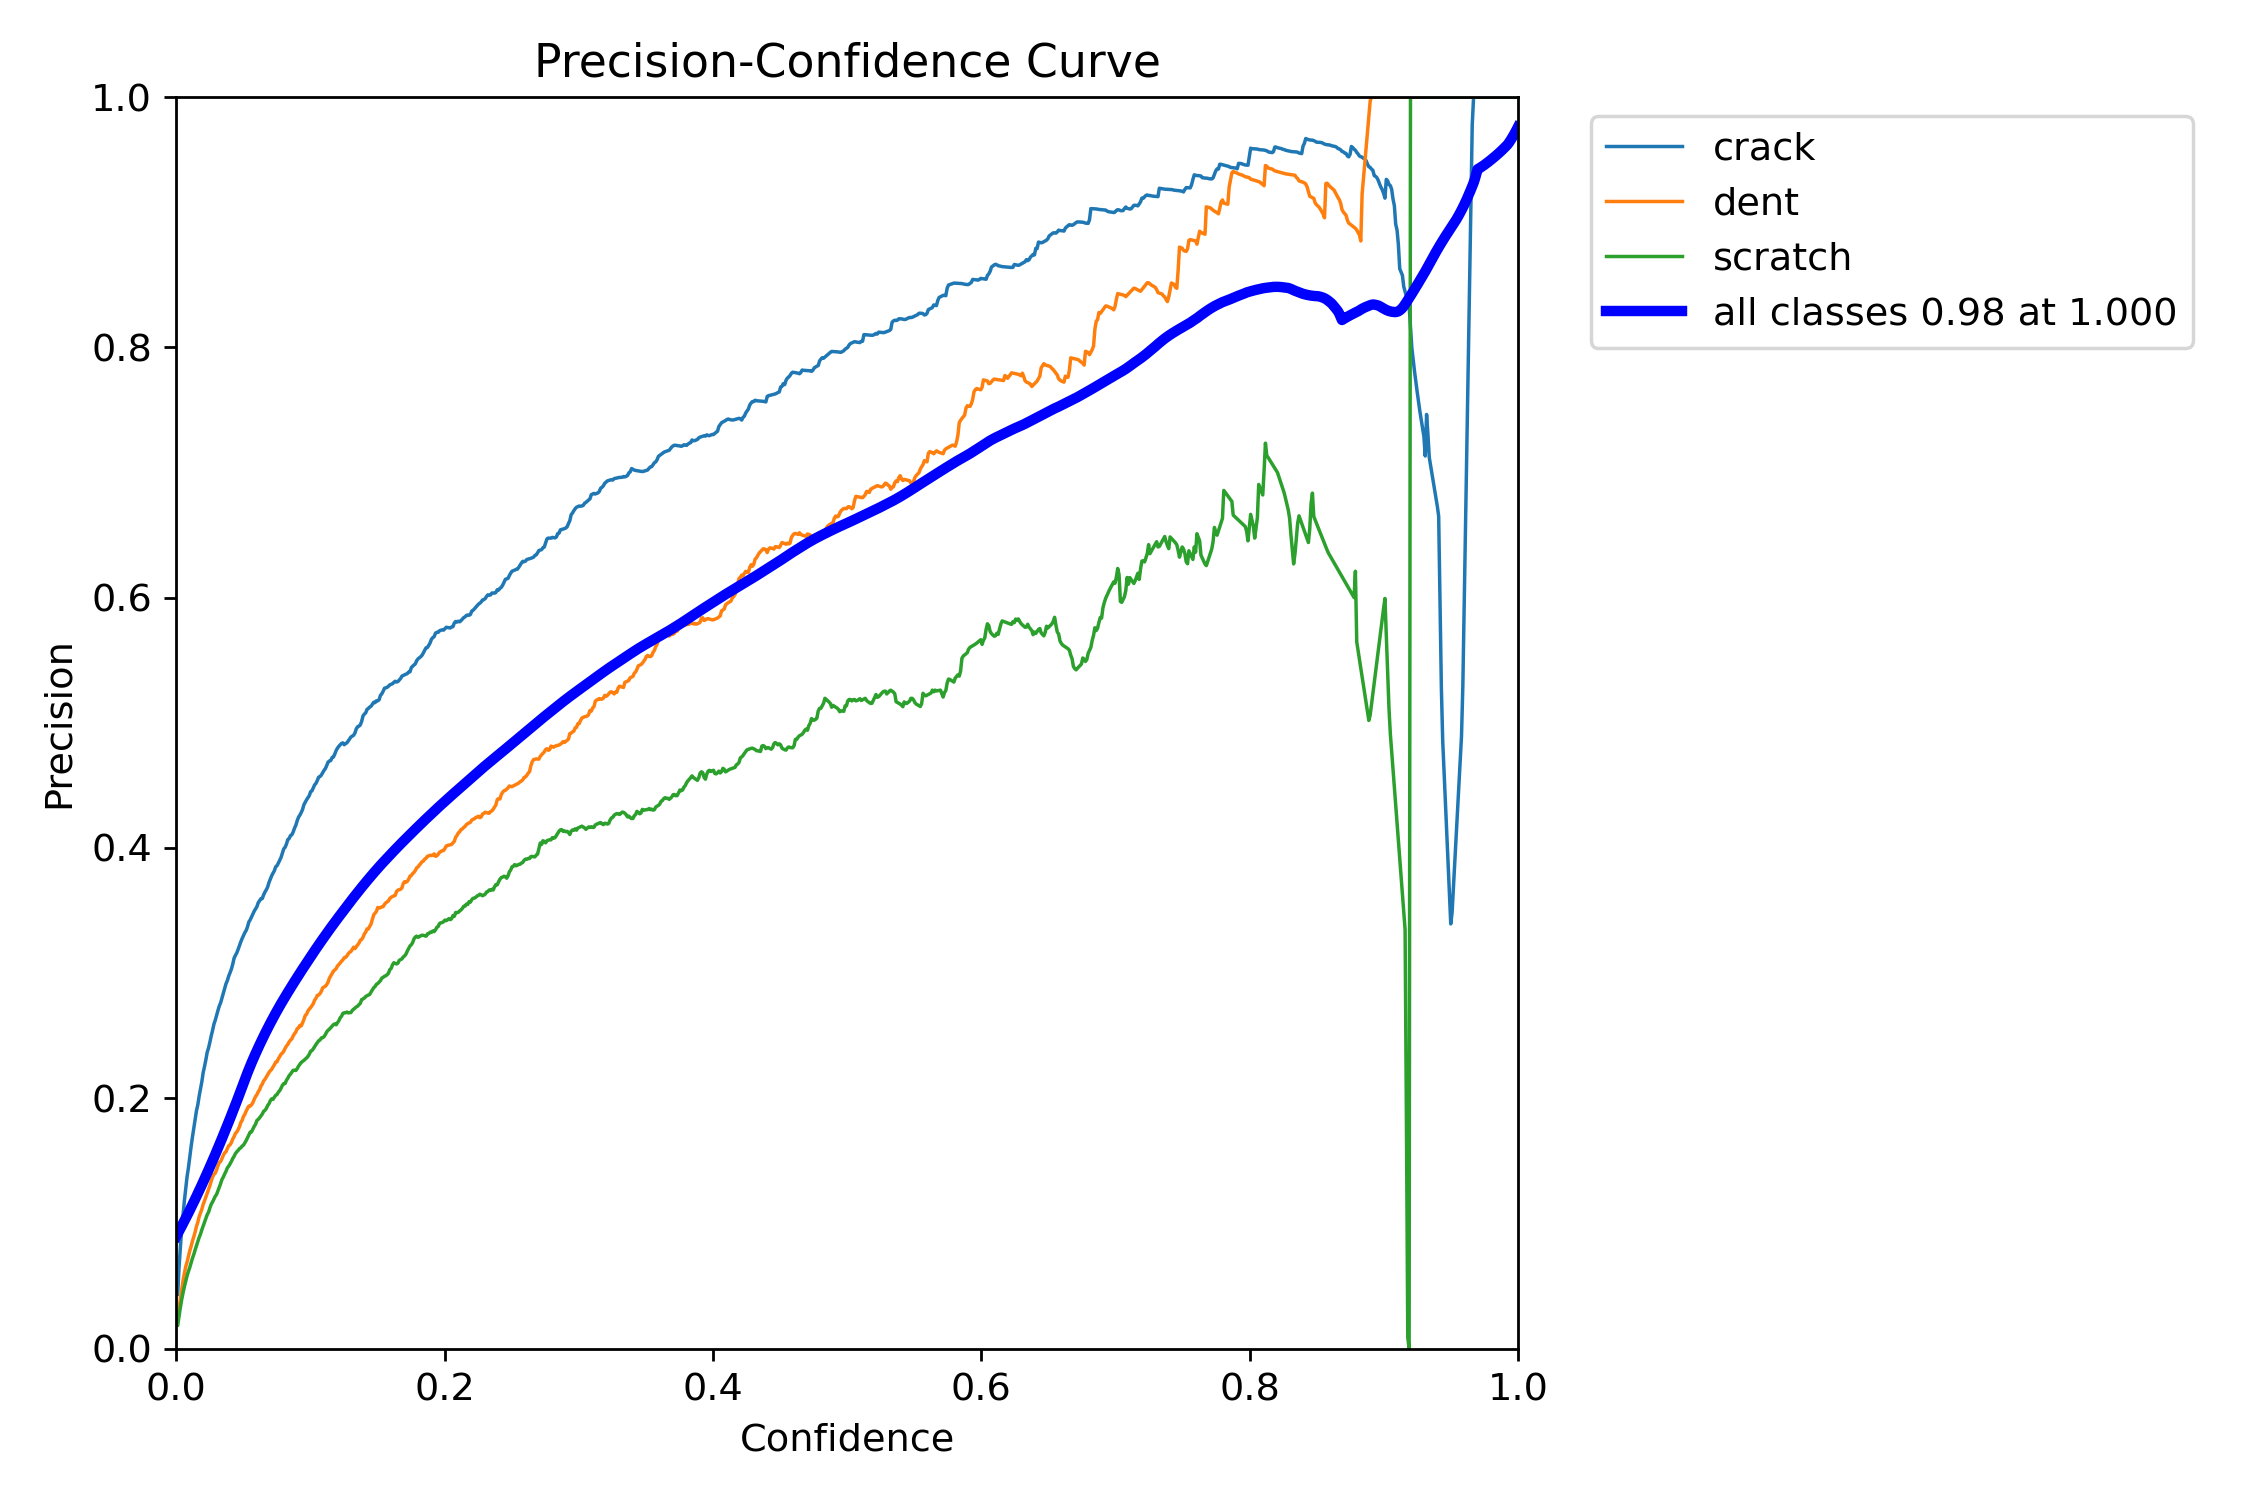


BoxR_curve.png
Esiste? True


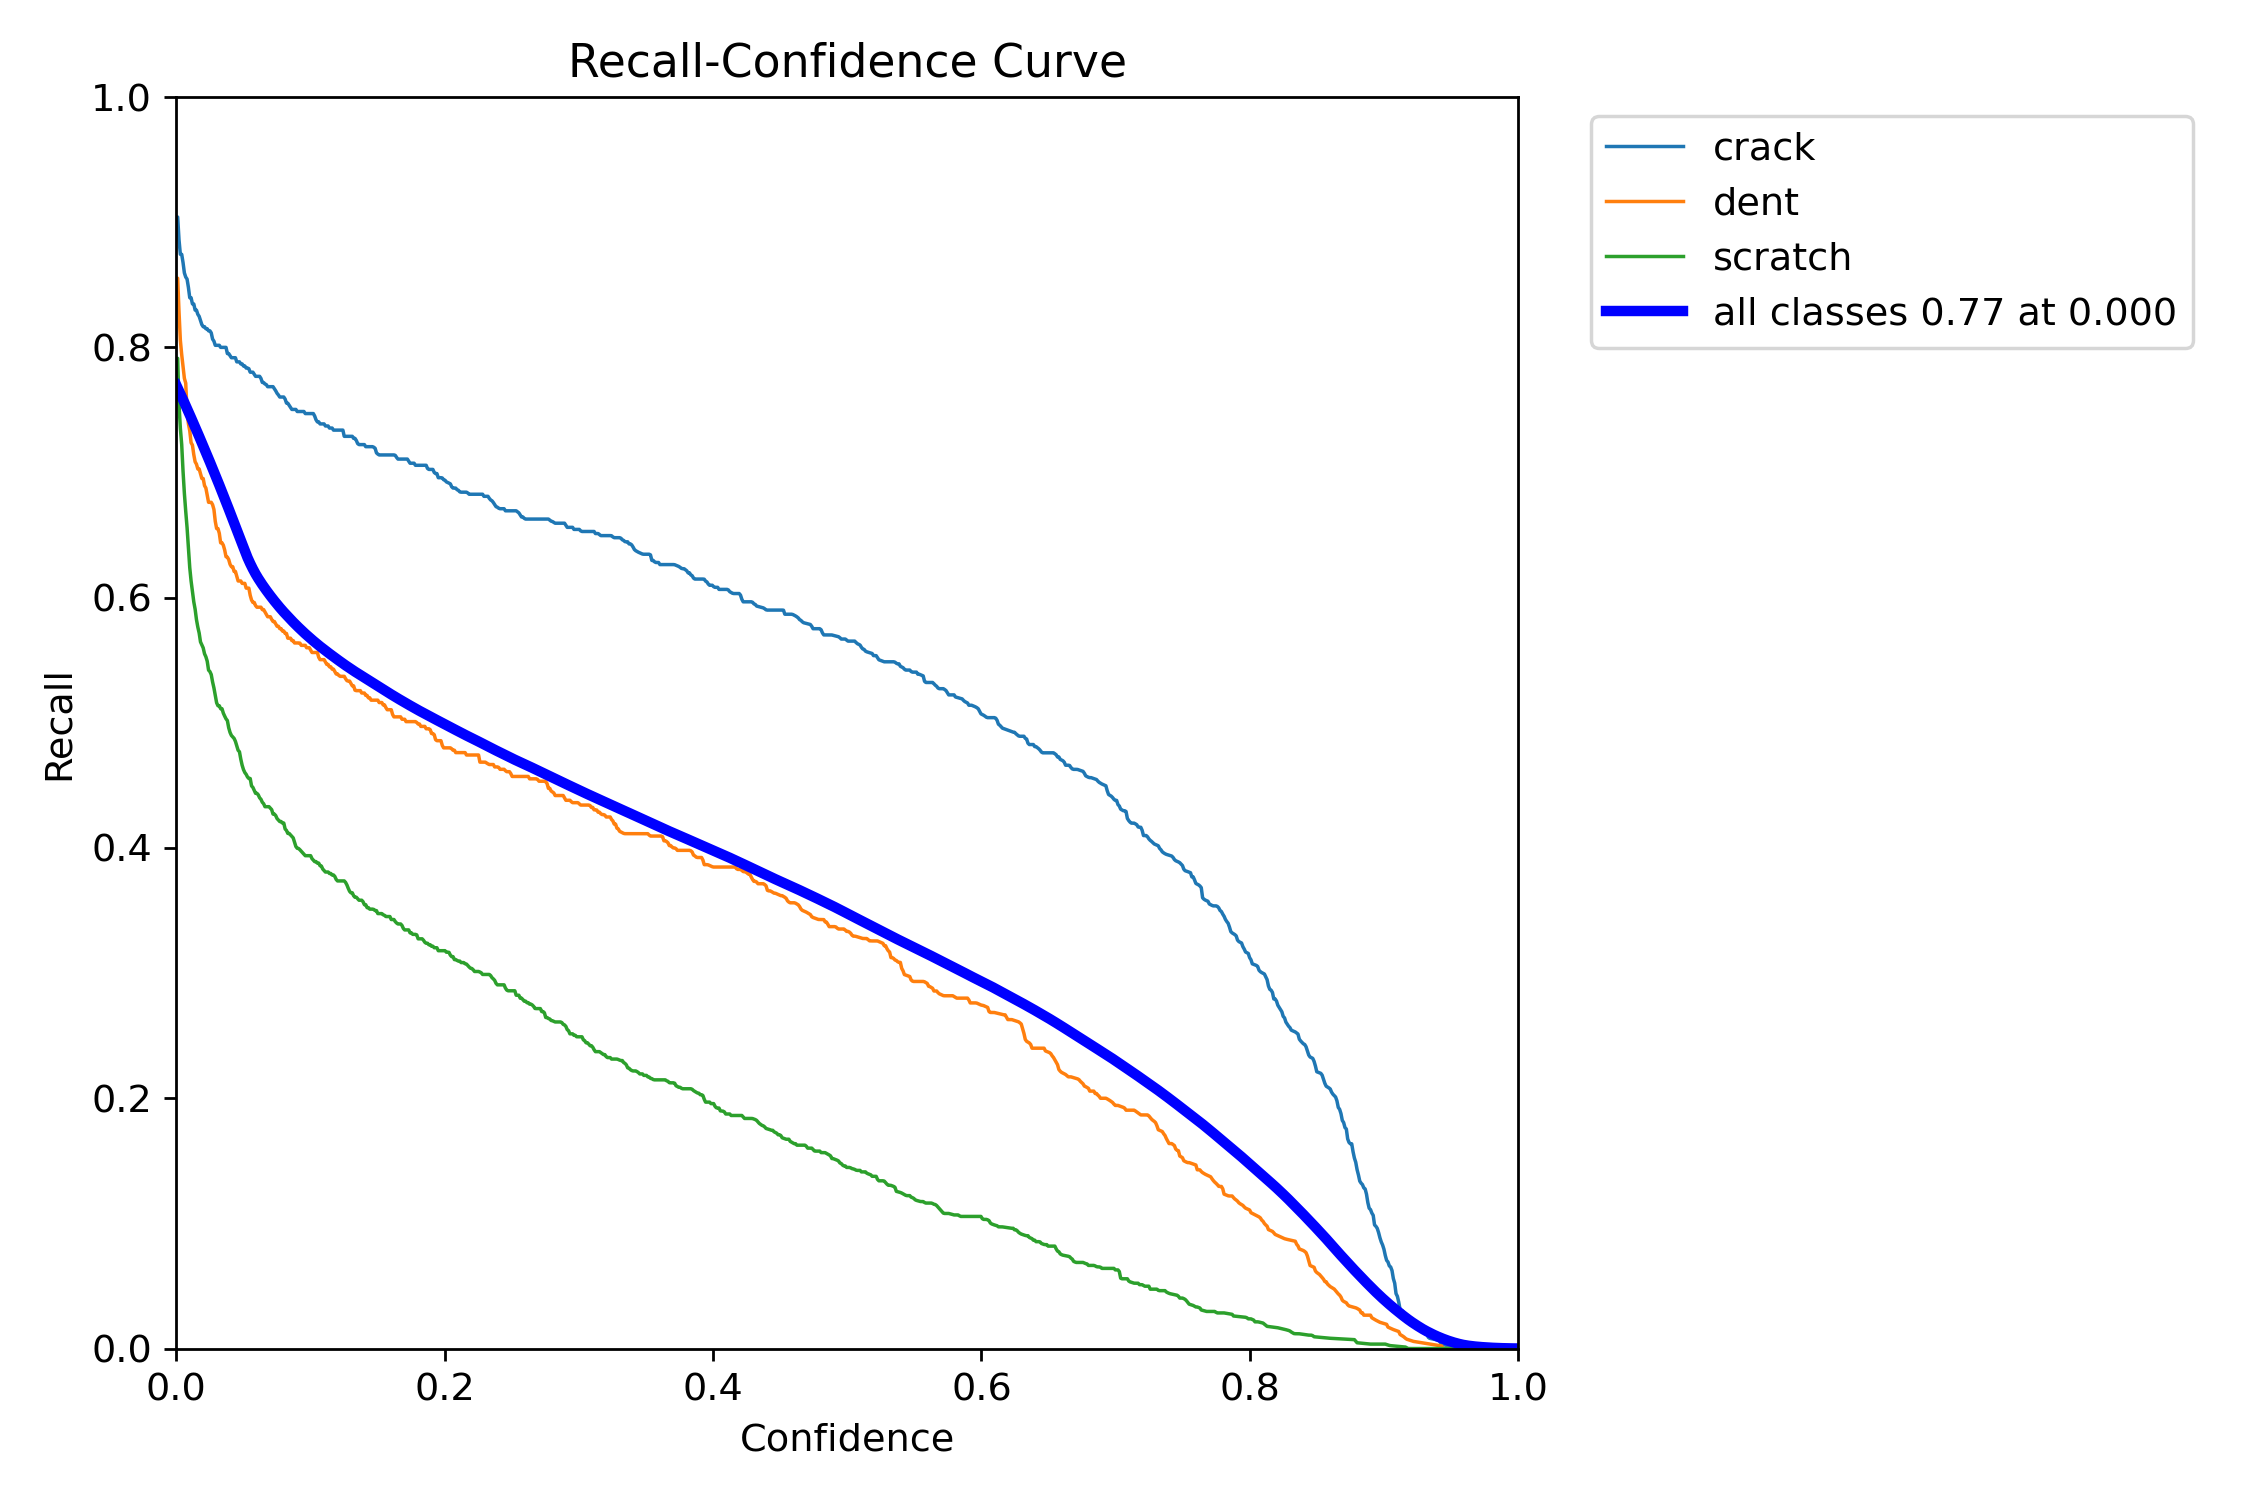

In [ ]:
from pathlib import Path
from IPython.display import Image, display

TRAIN_DIR = Path(DRIVE_PROJECT_DIR) / RUN_NAME

files_to_show = [
    "results.png",
    "labels.jpg",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png"
]

for file_name in files_to_show:
    file_path = TRAIN_DIR / file_name

    print("\n" + "="*80)
    print(file_name)
    print("Esiste?", file_path.exists())

    if file_path.exists():
        display(Image(filename=str(file_path), width=900))
    else:
        print("File non trovato:", file_path)

## 9. Predizione sulle immagini di validazione


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.

image 1/902 /content/car_damage_dataset/valid/images/002_jpg.rf.cc8f38012f08bb60dae4c2a74a43365f.jpg: 1024x1024 1 scratch, 14.2ms
image 2/902 /content/car_damage_dataset/valid/images/003_jpg.rf.a927a2bba3cdee5e9c51c37de3071c41.jpg: 1024x1024 3 scratchs, 14.3ms
image 3/902 /content/car_damage_dataset/valid/images/004_jpg.rf.2131343ccf4090bbbe67cbe6d0899dea.jpg: 1024x1024 4 scratchs, 14.2ms
image 4/902 /content/car_damage_dataset/valid/images/005_jpg.rf.98db6f2ba2d75e1feef900bea4f4d56d.jpg: 1024x1024 2 scratchs, 14.2ms
image 5/902 /content/car_damage_dataset/valid/images/006_jpg.rf.5841ca19f3c9e6cf2f4ca81931c52498.jpg: 1024x1024 2 scratchs, 14.2ms
image 6/902 /content/car_damage_dataset/valid/images/009_jpg.rf.714c2970a194c32fb9ac584cba0d553f.jpg: 1024x1024 3 scratchs, 14.2ms
image 7/902 /content/car_damage_dataset/valid/images/0163_JPEG_jpg.rf.1f4f612d6afc72356a372739bdf75972.jpg: 1024x1024 1 cra

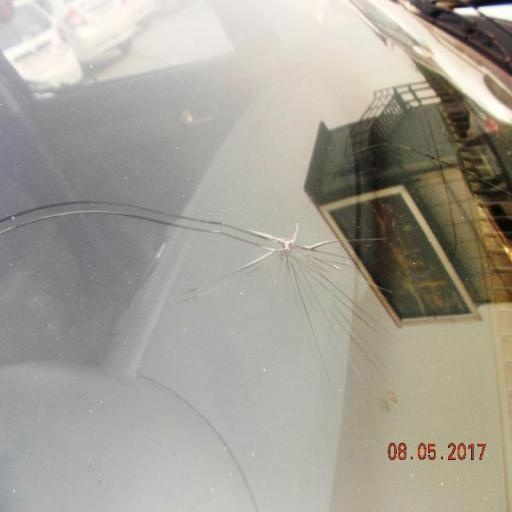

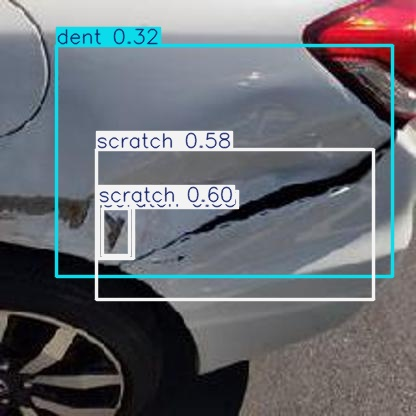

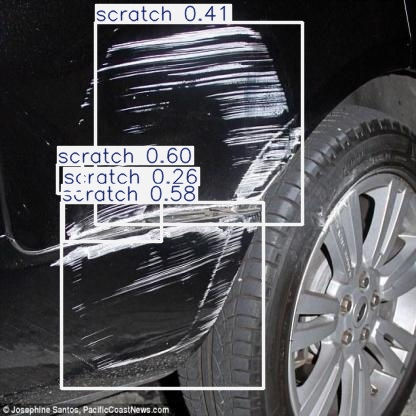

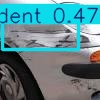

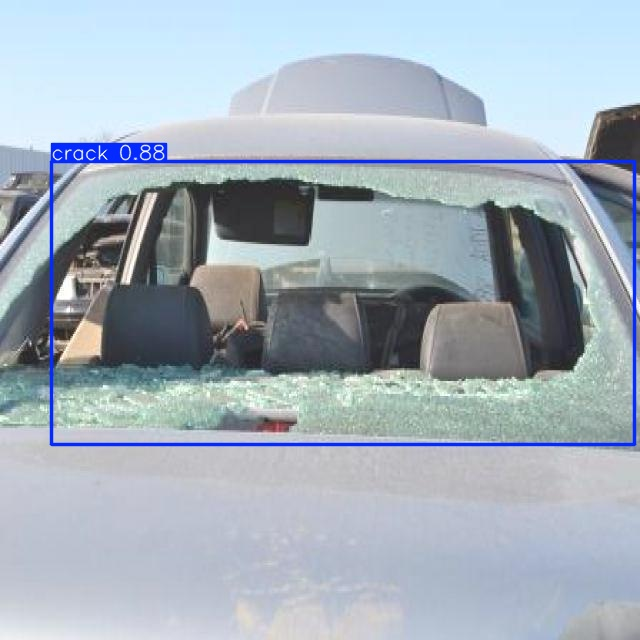

In [ ]:
from pathlib import Path
from IPython.display import Image, display

DATASET_DIR = Path('/content/car_damage_dataset')
CONF = 0.25

valid_images_dir = DATASET_DIR / 'valid' / 'images'

predict_results = loaded_model.predict(
    source=str(valid_images_dir),
    conf=CONF,
    save=True,
    device=0,      # usa la GPU
    half=False,
    imgsz=1024
)

predict_dir = Path(predict_results[0].save_dir)

print("Risultati salvati in:", predict_dir)

images = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    images.extend(predict_dir.glob(ext))

print("Numero immagini predette:", len(images))

for img_path in images[:5]:
    display(Image(filename=str(img_path), width=600))

## 10. Test su una nuova immagine caricata manualmente


In [ ]:
from google.colab import files
from pathlib import Path
from IPython.display import Image, display
from ultralytics import YOLO

# Se non hai già montato Drive, esegui prima:
from google.colab import drive
drive.mount('/content/drive')

# Variabili
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/yolo_car_damage_models'
RUN_NAME = 'train_car_damage_yolo11n'
CONF = 0.25

EXISTING_BEST_MODEL_PATH = None

# Percorso del modello
if EXISTING_BEST_MODEL_PATH is not None:
    BEST_MODEL_PATH = Path(EXISTING_BEST_MODEL_PATH)
else:
    BEST_MODEL_PATH = Path(DRIVE_PROJECT_DIR) / RUN_NAME / 'weights' / 'best.pt'

# Controllo esistenza modello
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modello non trovato: {BEST_MODEL_PATH}\n"
        "Assicurati di aver eseguito il training oppure di aver impostato "
        "EXISTING_BEST_MODEL_PATH correttamente."
    )

# Caricamento modello
loaded_model = YOLO(str(BEST_MODEL_PATH))
print("Modello caricato da:", BEST_MODEL_PATH)

# Upload immagini
uploaded = files.upload()

# Predizione su ogni immagine caricata
for filename in uploaded.keys():
    image_path = Path('/content') / filename
    print("Predizione su:", image_path)

    predict_results = loaded_model.predict(
        source=str(image_path),
        conf=CONF,
        save=True
    )

    if predict_results:
        result_obj = predict_results[0]

        # Cartella dove Ultralytics salva l'immagine predetta
        save_dir = Path(result_obj.save_dir)

        # Immagine annotata salvata con lo stesso nome dell'originale
        annotated_image_path = save_dir / image_path.name

        if annotated_image_path.exists():
            print("Mostro l'immagine predetta da:", annotated_image_path)
            display(Image(filename=str(annotated_image_path), width=600))
        else:
            print("Immagine annotata non trovata in:", annotated_image_path)
    else:
        print("Nessun risultato di predizione da visualizzare.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modello caricato da: /content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/weights/best.pt


Saving ChatGPT Image 2 lug 2026, 17_24_36.png to ChatGPT Image 2 lug 2026, 17_24_36.png
Predizione su: /content/ChatGPT Image 2 lug 2026, 17_24_36.png

image 1/1 /content/ChatGPT Image 2 lug 2026, 17_24_36.png: 768x1024 2 cracks, 1 dent, 1 scratch, 12.8ms
Speed: 7.2ms preprocess, 12.8ms inference, 3.8ms postprocess per image at shape (1, 3, 768, 1024)
Results saved to /content/runs/detect/predict-8
Immagine annotata non trovata in: /content/runs/detect/predict-8/ChatGPT Image 2 lug 2026, 17_24_36.png


## 11. Verifica del salvataggio su Drive


In [ ]:
weights_dir = Path(DRIVE_PROJECT_DIR) / RUN_NAME / 'weights'

print('Cartella pesi:', weights_dir)
print('Best model presente:', (weights_dir / 'best.pt').exists())
print('Last model presente:', (weights_dir / 'last.pt').exists())

for file in sorted(weights_dir.glob('*.pt')):
    size_mb = file.stat().st_size / (1024 * 1024)
    print(f'{file.name}: {size_mb:.2f} MB')

Cartella pesi: /content/drive/MyDrive/yolo_car_damage_models/train_car_damage_yolo11n/weights
Best model presente: True
Last model presente: True
best.pt: 5.27 MB
last.pt: 20.32 MB


## 12. Sintesi finale del lavoro svolto

Nel notebook è stato sviluppato un workflow completo per la realizzazione del progetto di Deep Learning finalizzato al rilevamento automatico dei danni alla carrozzeria delle automobili.

In primo luogo, è stato utilizzato un dataset di immagini di veicoli danneggiati, organizzato nel formato YOLO e composto da annotazioni relative a diverse tipologie di danno. Successivamente, è stata scelta l’architettura YOLO11, una rete neurale recente per il task di object detection, in quanto adatta all’individuazione e alla classificazione di oggetti all’interno delle immagini tramite bounding box.

Il modello pre-addestrato è stato quindi adattato al problema specifico attraverso una fase di fine-tuning sulle classi presenti nel dataset. Al termine dell’addestramento, il modello è stato valutato sul validation set, analizzando le principali metriche di object detection, come precision, recall e mAP.

Inoltre, sono state generate predizioni visive su immagini di validazione, mostrando le bounding box prodotte dal modello e la classe di danno rilevata. Questa fase ha permesso di verificare qualitativamente il comportamento del sistema e la sua capacità di localizzare i danni nelle immagini.

Infine, i pesi del modello addestrato, in particolare i file `best.pt` e `last.pt`, sono stati salvati su Google Drive. In questo modo, i risultati dell’addestramento vengono conservati in modo permanente e non vengono persi alla chiusura della sessione di Google Colab.
